# Univariate Exploratory Data Analysis — `epa-full.csv`

**Input:** `data/final/epa-full.csv` — the terminal (T1) modeling table produced by
the merge pipeline described in `MERGE.md`. One row per water-quality observation
(`MonitoringLocationIdentifier` × `ActivityStartDateTime`), joined to climate, weather,
streamflow, soil, land-cover, nutrient-loading and agricultural-context attributes.

**Scope:** *univariate only* — one variable at a time. No pairwise correlation, no
target–feature relationships, no modeling. Those belong in a later bivariate /
multivariate notebook.

**What this notebook covers**

| § | Section |
|---|---------|
| 1 | Dataset overview — shape, dtypes, date range, record grain |
| 2 | Column taxonomy — grouping 315 columns into source domains |
| 3 | Missingness — completeness per column and per domain |
| 4 | The 12 water-quality **targets** — units, distributions, skew, outliers, censoring |
| 5 | The 30 model **features** — distributions and degenerate-column checks |
| 6 | Categorical & identifier columns — cardinality and value counts |
| 7 | Temporal coverage — observations per year / month / day-of-year |
| 8 | Automated data-quality flags |
| 9 | Findings |
| 10 | **Red flags** — what to fix before quoting any model metric |

Summary tables are written to `src/04_eda/outputs/`.

## 0. Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.4g}")

# Locate the repo root from wherever the kernel was started.
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "data" / "final").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

DATA_PATH = REPO_ROOT / "data" / "final" / "epa-full.csv"
OUT_DIR = REPO_ROOT / "src" / "04_eda" / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("repo root :", REPO_ROOT)
print("data file :", DATA_PATH.relative_to(REPO_ROOT), f"({DATA_PATH.stat().st_size / 1e6:.1f} MB)")
print("outputs   :", OUT_DIR.relative_to(REPO_ROOT))

repo root : /Users/owenm/Documents/Owens_files/College Stuff/Research Projects/STEEN Fellowship Project 2026/workspace/Water-Quality-Prediction
data file : data/final/epa-full.csv (81.0 MB)
outputs   : src/04_eda/outputs


### Plot style

A single recessive style for the whole notebook: one hue for magnitude, thin marks, a
muted grid behind the data, no chart junk. Categorical hues are drawn from a fixed,
colourblind-validated order and are never cycled.

In [2]:
SURFACE   = "#ffffff"
INK       = "#0b0b0b"
INK_SOFT  = "#52514e"
GRIDLINE  = "#dcdbd6"
AXISLINE  = "#b8b7b2"

# Fixed categorical order (validated for CVD separation); slot 1 doubles as the
# single hue used for every magnitude chart.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE, ORANGE, AQUA, RED = SERIES[0], SERIES[1], SERIES[2], SERIES[7]

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": AXISLINE,
    "axes.labelcolor": INK_SOFT,
    "axes.titlecolor": INK,
    "axes.titlesize": 10,
    "axes.titleweight": "medium",
    "axes.labelsize": 8.5,
    "text.color": INK,
    "xtick.color": INK_SOFT,
    "ytick.color": INK_SOFT,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.frameon": False,
    "figure.dpi": 110,
    "savefig.dpi": 110,
})


def style_axes(ax, axis="y"):
    """Recessive grid + two spines. Grid sits behind the marks."""
    ax.grid(axis=axis, color=GRIDLINE, linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_linewidth(0.8)
    ax.tick_params(length=0)
    return ax


def thousands(ax, axis="y"):
    fmt = FuncFormatter(lambda v, _: f"{v:,.0f}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)
    return ax

## 1. Dataset overview

In [3]:
DATE_COL = "ActivityStartDateTime"
ID_COL = "MonitoringLocationIdentifier"

df = pd.read_csv(DATA_PATH, parse_dates=[DATE_COL])
print(f"rows    : {df.shape[0]:,}")
print(f"columns : {df.shape[1]:,}")
print(f"memory  : {df.memory_usage(deep=True).sum() / 1e6:,.0f} MB")

rows    : 48,251
columns : 315
memory  : 196 MB


In [4]:
dtype_counts = df.dtypes.astype(str).value_counts().rename_axis("dtype").to_frame("n_columns")
dtype_counts["pct"] = (100 * dtype_counts["n_columns"] / df.shape[1]).round(1)
dtype_counts

,n_columns,pct
dtype,,
float64,255,81
str,39,12.4
int64,17,5.4
bool,2,0.6
datetime64[us],1,0.3
object,1,0.3


In [5]:
overview = {
    "rows": len(df),
    "columns": df.shape[1],
    "unique monitoring stations": df[ID_COL].nunique(),
    "unique organizations": df["OrganizationIdentifier"].nunique(),
    "unique HUC-12 watersheds": df["huc12_code"].nunique(),
    "unique counties": df["county_fips"].nunique(),
    "first observation": df[DATE_COL].min(),
    "last observation": df[DATE_COL].max(),
    "fully duplicated rows": int(df.duplicated().sum()),
    "duplicate (station, datetime) keys": int(df.duplicated(subset=[ID_COL, DATE_COL]).sum()),
    "rows with a null station id": int(df[ID_COL].isna().sum()),
    "rows with a null timestamp": int(df[DATE_COL].isna().sum()),
}
pd.Series(overview, name="value").to_frame()

,value
rows,48251
columns,315
unique monitoring stations,1345
unique organizations,21
unique HUC-12 watersheds,555
unique counties,99
first observation,2015-01-02 10:45:00
last observation,2025-12-25 03:30:00
fully duplicated rows,0
"duplicate (station, datetime) keys",0


The grain claim to verify is **one row per station-visit**. A non-zero
`duplicate (station, datetime) keys` count means the merge produced more than one row for a
single visit — worth knowing before any distribution below is read as "per observation".

In [6]:
# Rows per station-visit key, to confirm/deny the grain.
per_key = df.groupby([ID_COL, DATE_COL], observed=True).size()
print(per_key.value_counts().rename_axis("rows_per_key").to_frame("n_keys").head(10))

              n_keys
rows_per_key        
1              48251


## 2. Column taxonomy

315 columns is too many to eyeball one at a time. Every column carries a source-domain
prefix from the merge pipeline (`prism_`, `isu_`, `chemapp__`, …); grouping on those
prefixes turns the wide table into ~15 blocks that can be reasoned about as units.

In [7]:
# The dashboard/model contract, mirrored from app.py so the EDA looks at exactly
# the columns the models consume. Keep in sync with app.py::FEATURE_COLS.
TARGET_COLS = {
    "Water Temperature":      "Temperature, water_value",
    "Dissolved Oxygen":       "Dissolved oxygen (DO)_value",
    "pH":                     "pH_value",
    "Nitrate":                "Nitrate_value",
    "Nitrite":                "Nitrite_value",
    "Nitrate + Nitrite":      "Nitrate + Nitrite_value",
    "Total Phosphorus":       "Total Phosphorus, mixed forms_value",
    "Specific Conductance":   "Specific conductance_value",
    "Total Dissolved Solids": "Total dissolved solids_value",
    "Total Suspended Solids": "Total suspended solids_value",
    "Turbidity":              "Turbidity_value",
    "E. coli":                "Escherichia coli_value",
}

BASE_FEATURE_COLS = [
    "LatitudeMeasure", "LongitudeMeasure",
    "distance_to_climate_station_km", "distance_to_streamflow_gauge_km",
    "prism_tmax_c", "prism_tmin_c", "prism_ppt_mm", "prism_tdmean_c",
    "isu_avg_wind_speed_kts", "isu_avg_rh", "isu_snow_in", "isu_snowd_in",
    "isu_max_feel_c", "isu_min_feel_c",
    "streamflow_discharge_cfs",
    "ksat_mean", "awc_mean",
    "pct_corn", "pct_soybean", "pct_developed", "pct_forest", "pct_row_crops",
    "npfert__n__total_kg", "npfert__p__total_kg",
    "npmanure__total__n_kg", "npmanure__total__p_kg",
]
TEMPORAL_FEATURE_COLS = ["doy", "doy_sin", "doy_cos", "obs_year"]
FEATURE_COLS = BASE_FEATURE_COLS + TEMPORAL_FEATURE_COLS

assert len(FEATURE_COLS) == 30, len(FEATURE_COLS)
missing_base = [c for c in BASE_FEATURE_COLS if c not in df.columns]
print("target columns present :", sum(c in df.columns for c in TARGET_COLS.values()), "/", len(TARGET_COLS))
print("base features missing  :", missing_base or "none")

target columns present : 12 / 12
base features missing  : none


In [8]:
# The 4 temporal features are derived at inference time in app.py; derive them here
# so they can be profiled alongside the 26 base features.
df["doy"] = df[DATE_COL].dt.dayofyear
df["doy_sin"] = np.sin(2 * np.pi * df["doy"] / 365.25)
df["doy_cos"] = np.cos(2 * np.pi * df["doy"] / 365.25)
df["obs_year"] = df[DATE_COL].dt.year
df["obs_month"] = df[DATE_COL].dt.month

TARGET_VALUE_COLS = [c for c in TARGET_COLS.values() if c in df.columns]
ALL_WQ_VALUE_COLS = [c for c in df.columns if c.endswith("_value")]
UNIT_COLS = [c for c in df.columns if c.endswith("_unit")]
print(f"{len(ALL_WQ_VALUE_COLS)} water-quality analytes in the table; {len(TARGET_VALUE_COLS)} are modeling targets")
print("non-target analytes:", [c.replace('_value', '') for c in ALL_WQ_VALUE_COLS if c not in TARGET_VALUE_COLS])

23 water-quality analytes in the table; 12 are modeling targets
non-target analytes: ['Ammonia-nitrogen', 'Kjeldahl nitrogen', 'Orthophosphate', 'Phosphate-phosphorus', 'Chloride', 'Sulfate', 'Chlorophyll a, free of pheophytin', 'Microcystin', 'Atrazine', 'Alkalinity, total', 'Hardness, carbonate']


In [9]:
def column_domain(col: str) -> str:
    """Map a column name to its source domain in the merge pipeline."""
    if col in TARGET_VALUE_COLS:
        return "wq target"
    if col in ALL_WQ_VALUE_COLS:
        return "wq non-target analyte"
    if col in UNIT_COLS:
        return "measurement unit"
    if col in TEMPORAL_FEATURE_COLS + ["obs_month"]:
        return "temporal (derived)"
    for prefix, domain in [
        ("prism_", "climate (PRISM)"),
        ("isu_", "weather (ISU/ASOS)"),
        ("streamflow_", "streamflow (USGS)"),
        ("bmp__", "conservation BMPs"),
        ("npdes__", "point sources (NPDES)"),
        ("cropyield__", "crop yield (NASS)"),
        ("livestock__", "livestock (NASS)"),
        ("npfert__", "nutrient budget: fertilizer"),
        ("npmanure__", "nutrient budget: manure"),
        ("chemapp__", "chemical application (NASS)"),
        ("spend__", "farm expenditure (NASS)"),
        ("pct_", "land cover (CDL)"),
    ]:
        if col.startswith(prefix):
            return domain
    if col in {"mukey", "map_unit_symbol", "map_unit_name", "survey_area", "soil_match_method",
               "soil_match_distance_m", "dominant_component", "dominant_component_pct",
               "hydrologic_group", "drainage_class", "ksat_mean", "awc_mean"}:
        return "soil (SSURGO)"
    if col in {"huc12_code", "huc12_name", "huc10_code", "huc8_code", "huc12_acres",
               "HUCEightDigitCode", "county_fips", "StateCode", "CountyCode"}:
        return "geography / watershed"
    if col in {"np_base_year", "np_years_stale", "cattle_head_ratio", "hog_head_ratio",
               "manure_cattle_refreshed", "manure_hogs_refreshed"}:
        return "nutrient budget: provenance"
    if col in {"climate_station", "distance_to_climate_station_km", "climate_station_name"}:
        return "climate (PRISM)"
    return "station identity / metadata"


domains = pd.Series({c: column_domain(c) for c in df.columns}, name="domain")

domain_summary = (
    pd.DataFrame({"domain": domains, "completeness": df.notna().mean()})
    .groupby("domain", observed=True)
    .agg(n_columns=("domain", "size"),
         mean_completeness=("completeness", "mean"),
         min_completeness=("completeness", "min"),
         max_completeness=("completeness", "max"))
    .sort_values("n_columns", ascending=False)
)
domain_summary[["mean_completeness", "min_completeness", "max_completeness"]] *= 100
domain_summary.round(1)

,n_columns,mean_completeness,min_completeness,max_completeness
domain,,,,
chemical application (NASS),98,27.1,7.8,46.2
livestock (NASS),29,19.4,2.3,100
crop yield (NASS),28,29.8,0,94.5
measurement unit,23,29.1,3,71.9
weather (ISU/ASOS),14,90.4,47.5,95.2
soil (SSURGO),12,78.5,62.9,100
wq target,12,37.8,9.7,71.9
farm expenditure (NASS),12,95.9,95.9,95.9
wq non-target analyte,11,19.6,3,46


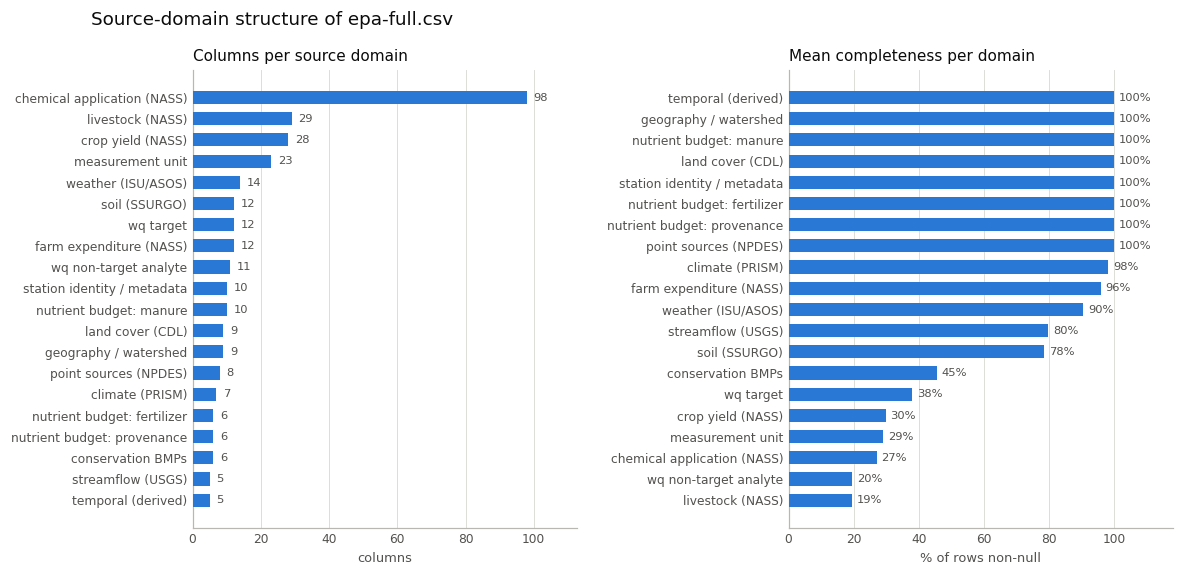

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.4), gridspec_kw={"wspace": 0.55})

order = domain_summary.sort_values("n_columns")
ax = axes[0]
ax.barh(order.index, order["n_columns"], color=BLUE, height=0.62, zorder=3)
for label, v in zip(order.index, order["n_columns"]):
    ax.text(v + 2, label, f"{v:,}", va="center", fontsize=7.5, color=INK_SOFT)
style_axes(ax, axis="x")
ax.set_xlim(0, order["n_columns"].max() * 1.15)
ax.set_title("Columns per source domain", loc="left")
ax.set_xlabel("columns")

order2 = domain_summary.sort_values("mean_completeness")
ax = axes[1]
ax.barh(order2.index, order2["mean_completeness"], color=BLUE, height=0.62, zorder=3)
for label, v in zip(order2.index, order2["mean_completeness"]):
    ax.text(v + 1.5, label, f"{v:.0f}%", va="center", fontsize=7.5, color=INK_SOFT)
style_axes(ax, axis="x")
ax.set_xlim(0, 118)
ax.set_title("Mean completeness per domain", loc="left")
ax.set_xlabel("% of rows non-null")

fig.suptitle("Source-domain structure of epa-full.csv", x=0.045, ha="left", fontsize=12, color=INK)
plt.show()

## 3. Missingness

Completeness is the first univariate property of any column: a variable that is 95% null
is a different object from one that is 5% null, no matter what its histogram looks like.

In [11]:
completeness = (
    pd.DataFrame({
        "domain": domains,
        "dtype": df.dtypes.astype(str),
        "n_present": df.notna().sum(),
        "pct_present": 100 * df.notna().mean(),
        "n_unique": df.nunique(dropna=True),
    })
    .rename_axis("column")
    .sort_values("pct_present")
)
completeness.to_csv(OUT_DIR / "column_completeness.csv")
print(f"wrote {OUT_DIR / 'column_completeness.csv'}")
completeness.head(25).round(2)

wrote /Users/owenm/Documents/Owens_files/College Stuff/Research Projects/STEEN Fellowship Project 2026/workspace/Water-Quality-Prediction/src/04_eda/outputs/column_completeness.csv


,domain,dtype,n_present,pct_present,n_unique
column,,,,,
cropyield__corn_traditional_or_indian__production__census,crop yield (NASS),float64,20,0.04,1
cropyield__wheat_spring_excl_durum__production__census,crop yield (NASS),float64,21,0.04,2
cropyield__barley__production__census,crop yield (NASS),float64,22,0.05,2
livestock__goats_angora__inventory__census,livestock (NASS),float64,1087,2.25,22
Atrazine_value,wq non-target analyte,float64,1450,3.01,632
Atrazine_unit,measurement unit,str,1450,3.01,1
cropyield__wheat_winter__production__census,crop yield (NASS),float64,2033,4.21,53
livestock__goats_angora__operations_with_inventory__census,livestock (NASS),float64,2187,4.53,9
cropyield__rye__production__census,crop yield (NASS),float64,2402,4.98,52


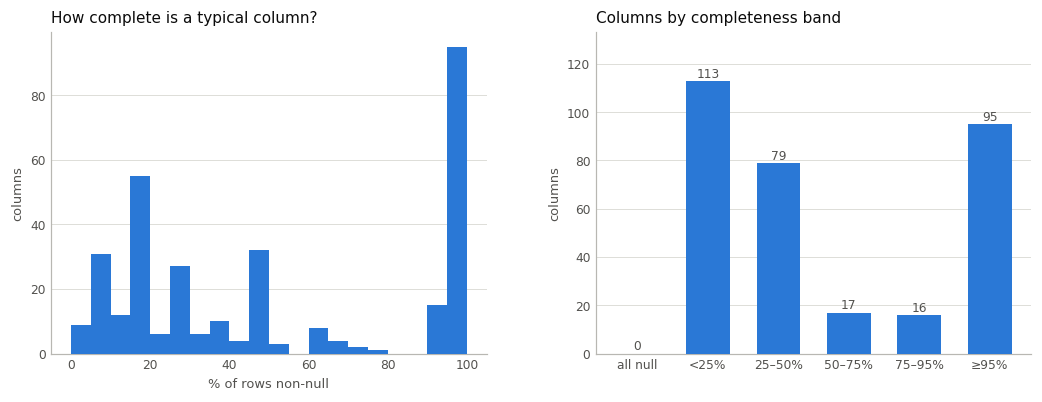

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8), gridspec_kw={"wspace": 0.25})

ax = axes[0]
ax.hist(completeness["pct_present"], bins=np.arange(0, 105, 5), color=BLUE, zorder=3)
style_axes(ax)
ax.set_title("How complete is a typical column?", loc="left")
ax.set_xlabel("% of rows non-null")
ax.set_ylabel("columns")

ax = axes[1]
bands = pd.cut(completeness["pct_present"],
               bins=[-0.01, 0.01, 25, 50, 75, 95, 100],
               labels=["all null", "<25%", "25–50%", "50–75%", "75–95%", "≥95%"])
counts = bands.value_counts().reindex(["all null", "<25%", "25–50%", "50–75%", "75–95%", "≥95%"])
ax.bar(counts.index, counts.values, color=BLUE, width=0.62, zorder=3)
for x, v in zip(counts.index, counts.values):
    ax.text(x, v + 1.5, f"{v}", ha="center", fontsize=8, color=INK_SOFT)
style_axes(ax)
ax.set_ylim(0, counts.max() * 1.18)
ax.set_title("Columns by completeness band", loc="left")
ax.set_ylabel("columns")

plt.show()

In [13]:
all_null = completeness.index[completeness["n_present"] == 0].tolist()
constant = completeness.index[(completeness["n_unique"] <= 1) & (completeness["n_present"] > 0)].tolist()
near_empty = completeness.index[completeness["pct_present"].between(0.0001, 5)].tolist()

print(f"all-null columns ({len(all_null)}):")
for c in all_null:
    print("   ", c)
print(f"\nconstant (single-value) columns ({len(constant)}):")
for c in constant:
    print("   ", c, "=", df[c].dropna().iloc[0])
print(f"\n<5% populated columns ({len(near_empty)}):")
for c in near_empty:
    print("   ", c, f"{completeness.loc[c, 'pct_present']:.2f}%")

all-null columns (0):

constant (single-value) columns (45):
    cropyield__corn_traditional_or_indian__production__census = 300.0
    Atrazine_unit = ug/L
    Microcystin_unit = ug/L
    chemapp__corn__herbicide__24-d_2-ehe_lb = 225000.0
    chemapp__corn__insecticide__cyfluthrin_lb = 3000.0
    chemapp__corn__fungicide__metconazole_lb = 21000.0
    chemapp__corn__insecticide__tebupirimphos_lb = 64000.0
    chemapp__corn__herbicide__24-d_dimeth_salt_lb = 152000.0
    chemapp__soybeans__fungicide__prothioconazole_lb = 49000.0
    chemapp__soybeans__other__total_lb = 59000.0
    chemapp__soybeans__fungicide__trifloxystrobin_lb = 42000.0
    chemapp__soybeans__insecticide__zeta-cypermethrin_lb = 9000.0
    chemapp__soybeans__insecticide__imidacloprid_lb = 26000.0
    chemapp__soybeans__herbicide__dicamba;_bapma_lb = 235000.0
    chemapp__soybeans__insecticide__esfenvalerate_lb = 7000.0
    chemapp__soybeans__herbicide__quizalofop-p-ethyl_lb = 17000.0
    chemapp__soybeans__herbicide__lac

## 4. The 12 modeling targets

These are the columns the dashboard predicts. Each is examined for: unit consistency,
central tendency and spread, shape (skew / kurtosis), outliers, and reporting artefacts
(value pile-ups from laboratory detection limits or instrument ceilings).

### 4.1 Unit consistency

Every analyte column ships with a paired `_unit` column. If a single analyte were reported
in more than one unit, its distribution would be a mixture of two scales and every
statistic below — and every model trained on it — would be meaningless.

In [14]:
unit_rows = []
for label, col in TARGET_COLS.items():
    unit_col = col.replace("_value", "_unit")
    units = df.loc[df[col].notna(), unit_col]
    vc = units.value_counts(dropna=False)
    unit_rows.append({
        "target": label,
        "column": col,
        "n_observations": int(df[col].notna().sum()),
        "n_distinct_units": int(units.dropna().nunique()),
        "units": " | ".join(f"{u} ({n:,})" for u, n in vc.items()),
        "n_value_without_unit": int(units.isna().sum()),
    })
unit_table = pd.DataFrame(unit_rows).set_index("target")
unit_table.to_csv(OUT_DIR / "target_units.csv")
unit_table[["n_observations", "n_distinct_units", "units", "n_value_without_unit"]]

,n_observations,n_distinct_units,units,n_value_without_unit
target,,,,
Water Temperature,34705,1,"deg C (34,705)",0
Dissolved Oxygen,31825,1,"mg/L (31,825)",0
pH,32353,1,"std units (32,353)",0
Nitrate,12348,1,"mg/L as N (12,348)",0
Nitrite,11611,1,"mg/L as N (11,611)",0
Nitrate + Nitrite,4659,1,"mg/L as N (4,659)",0
Total Phosphorus,5886,1,"mg/L as P (5,886)",0
Specific Conductance,16067,1,"uS/cm (16,067)",0
Total Dissolved Solids,18011,1,"mg/L (18,011)",0


### 4.2 Descriptive statistics

In [15]:
def describe_numeric(frame: pd.DataFrame, cols, labels=None) -> pd.DataFrame:
    """Univariate summary: coverage, location, spread, shape, outliers, sign."""
    labels = labels or {c: c for c in cols}
    rows = []
    n_rows = len(frame)
    for c in cols:
        v = pd.to_numeric(frame[c], errors="coerce").dropna()
        if v.empty:
            rows.append({"variable": labels[c], "column": c, "n": 0, "pct_present": 0.0})
            continue
        q1, med, q3 = v.quantile([0.25, 0.50, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = int(((v < lo) | (v > hi)).sum())
        rows.append({
            "variable": labels[c],
            "column": c,
            "n": int(v.size),
            "pct_present": 100 * v.size / n_rows,
            "mean": v.mean(),
            "std": v.std(),
            "min": v.min(),
            "p1": v.quantile(0.01),
            "q1": q1,
            "median": med,
            "q3": q3,
            "p99": v.quantile(0.99),
            "max": v.max(),
            "iqr": iqr,
            "cv": v.std() / v.mean() if v.mean() else np.nan,
            "skew": v.skew(),
            "kurtosis": v.kurt(),
            "n_zero": int((v == 0).sum()),
            "n_negative": int((v < 0).sum()),
            "n_outlier_iqr": n_out,
            "pct_outlier_iqr": 100 * n_out / v.size,
            "n_unique": int(v.nunique()),
        })
    return pd.DataFrame(rows).set_index("variable")


target_stats = describe_numeric(df, TARGET_VALUE_COLS,
                                labels={v: k for k, v in TARGET_COLS.items()})
target_stats.to_csv(OUT_DIR / "target_univariate_stats.csv")
target_stats[["n", "pct_present", "mean", "std", "min", "q1", "median", "q3", "max"]].round(3)

,n,pct_present,mean,std,min,q1,median,q3,max
variable,,,,,,,,,
Water Temperature,34705,71.93,16.12,8.31,-1,10,18,23,37
Dissolved Oxygen,31825,65.96,9.125,2.674,0,7.9,8.809,10.51,24.6
pH,32353,67.05,7.99,0.658,4,7.8,8,8.3,11.76
Nitrate,12348,25.59,3.342,5.315,0,0,2,5,132.3
Nitrite,11611,24.06,0.023,0.137,0,0,0,0,3.4
Nitrate + Nitrite,4659,9.656,4.248,4.514,0,0.612,3.17,6.24,38.4
Total Phosphorus,5886,12.2,0.234,0.401,0,0.07,0.131,0.26,9.5
Specific Conductance,16067,33.3,505.5,202.1,0,404,504,577,"4,200"
Total Dissolved Solids,18011,37.33,336.8,123.7,9,260,330,398,"2,580"


In [16]:
target_stats[["skew", "kurtosis", "cv", "n_zero", "n_negative", "n_outlier_iqr",
              "pct_outlier_iqr", "n_unique"]].round(2)

,skew,kurtosis,cv,n_zero,n_negative,n_outlier_iqr,pct_outlier_iqr,n_unique
variable,,,,,,,,
Water Temperature,-0.45,-0.92,0.52,634,83,0,0,3790
Dissolved Oxygen,0.31,1.17,0.29,4,0,1675,5.26,1810
pH,-0.8,1.9,0.08,0,0,5344,16.52,773
Nitrate,3.79,39.54,1.59,4731,0,781,6.32,1095
Nitrite,13.46,238.1,5.91,9766,0,1845,15.89,299
Nitrate + Nitrite,2.05,6.87,1.06,5,0,162,3.48,961
Total Phosphorus,9.24,137.9,1.72,0,0,449,7.63,903
Specific Conductance,4.18,45.83,0.4,2,0,723,4.5,4012
Total Dissolved Solids,1.36,9.35,0.37,0,0,551,3.06,2394


### 4.3 Sample size per target

Coverage varies by an order of magnitude across the 12 targets — the number of rows a
model can actually train on is the first constraint on how well that target can be
predicted.

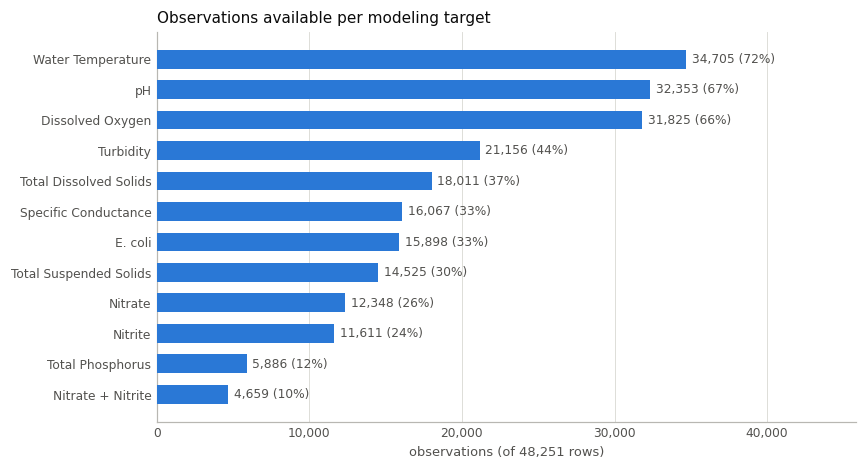

In [17]:
cov = target_stats["n"].sort_values()
fig, ax = plt.subplots(figsize=(8.2, 4.6))
ax.barh(cov.index, cov.values, color=BLUE, height=0.62, zorder=3)
for label, v in zip(cov.index, cov.values):
    ax.text(v + len(df) * 0.008, label, f"{v:,} ({100 * v / len(df):.0f}%)",
            va="center", fontsize=8, color=INK_SOFT)
style_axes(ax, axis="x")
thousands(ax, axis="x")
ax.set_xlim(0, cov.max() * 1.32)
ax.set_xlabel(f"observations (of {len(df):,} rows)")
ax.set_title("Observations available per modeling target", loc="left")
plt.show()

### 4.4 Distributions

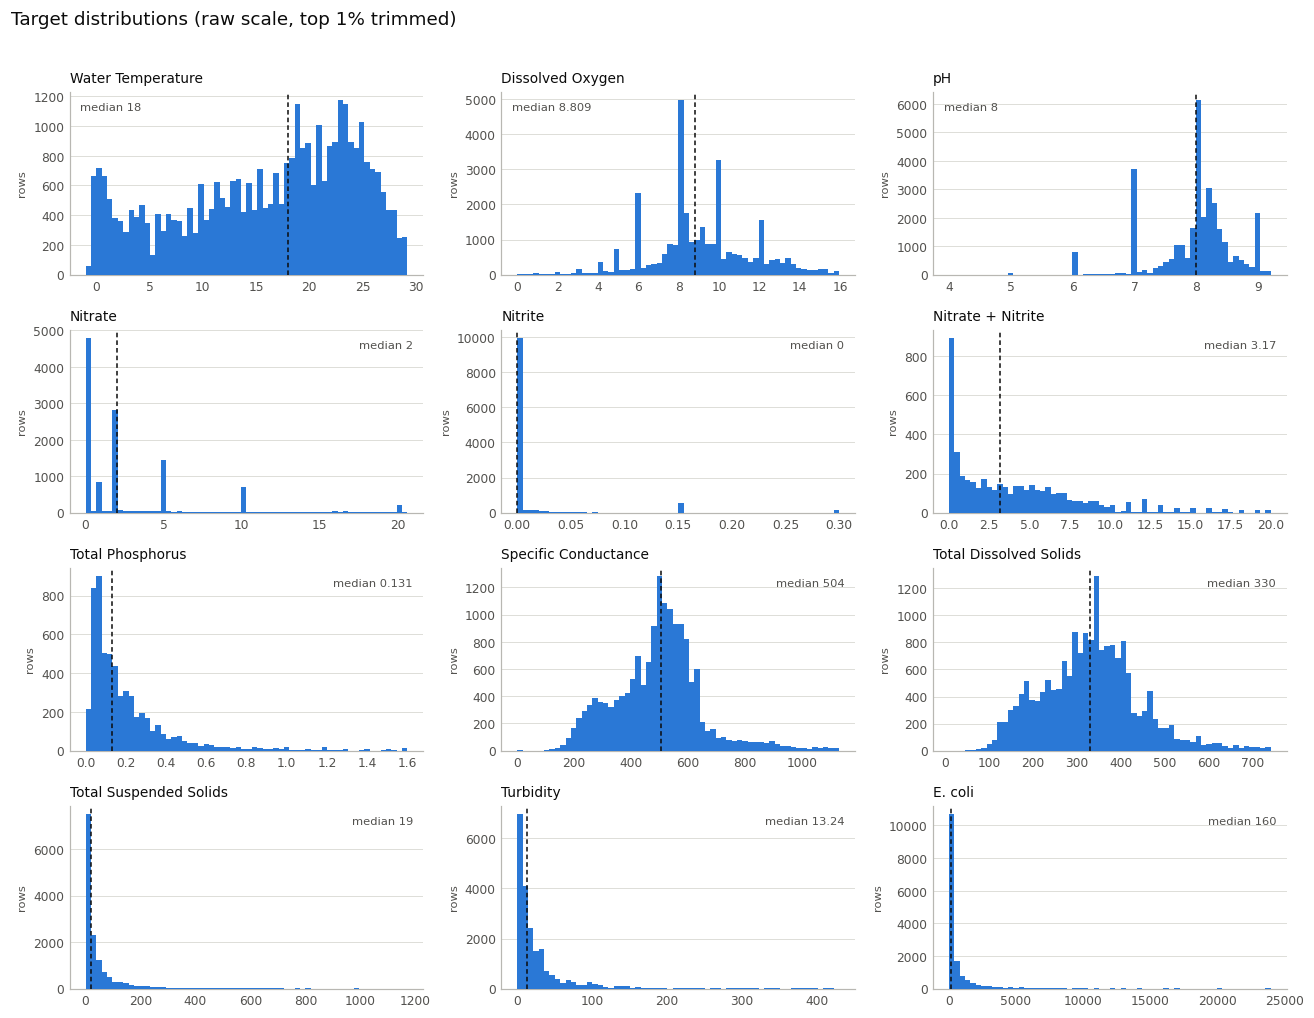

In [18]:
def hist_grid(frame, cols, labels=None, ncols=3, bins=60, log=False, clip=None,
              title=None, panel_h=2.35, color=BLUE):
    """Grid of histograms, one panel per column, with the median direct-labelled.

    log=True  -> log-spaced bins and a log x-axis (positive values only)
    clip=0.99 -> trim the top tail so the bulk of the distribution stays legible
    """
    labels = labels or {c: c for c in cols}
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, panel_h * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, c in zip(axes, cols):
        v = pd.to_numeric(frame[c], errors="coerce").dropna()
        if log:
            v = v[v > 0]
        if clip is not None and not v.empty:
            v = v[v <= v.quantile(clip)]
        if v.empty:
            ax.set_axis_off()
            continue
        if log:
            edges = np.logspace(np.log10(v.min()), np.log10(v.max()), bins)
            ax.set_xscale("log")
        else:
            edges = bins
        ax.hist(v, bins=edges, color=color, zorder=3)
        med = pd.to_numeric(frame[c], errors="coerce").median()
        if np.isfinite(med) and (not log or med > 0):
            ax.axvline(med, color=INK, linewidth=1.0, linestyle=(0, (3, 2)), zorder=4)
            # Park the label on whichever side the median line is not.
            lo_x, hi_x = ax.get_xlim()
            frac = ((np.log10(med) - np.log10(lo_x)) / (np.log10(hi_x) - np.log10(lo_x))
                    if log else (med - lo_x) / (hi_x - lo_x))
            left = frac > 0.5
            ax.text(0.03 if left else 0.97, 0.9, f"median {med:,.4g}",
                    transform=ax.transAxes, ha="left" if left else "right",
                    fontsize=7.5, color=INK_SOFT)
        style_axes(ax)
        ax.set_title(labels[c], loc="left", fontsize=9)
        ax.set_ylabel("rows", fontsize=7.5)

    for ax in axes[len(cols):]:
        ax.set_axis_off()
    if title:
        fig.suptitle(title, x=0.008, ha="left", fontsize=12, color=INK)
    fig.tight_layout(rect=(0, 0, 1, 0.97 if title else 1))
    plt.show()


hist_grid(df, TARGET_VALUE_COLS, labels={v: k for k, v in TARGET_COLS.items()},
          clip=0.99, title="Target distributions (raw scale, top 1% trimmed)")

Most of the chemistry and biology targets are strongly right-skewed and unreadable on a
raw axis. Replotted on a log axis, the same variables separate into two families:
roughly log-normal (concentrations, conductance, *E. coli*) versus bounded-symmetric
(temperature, pH, dissolved oxygen).

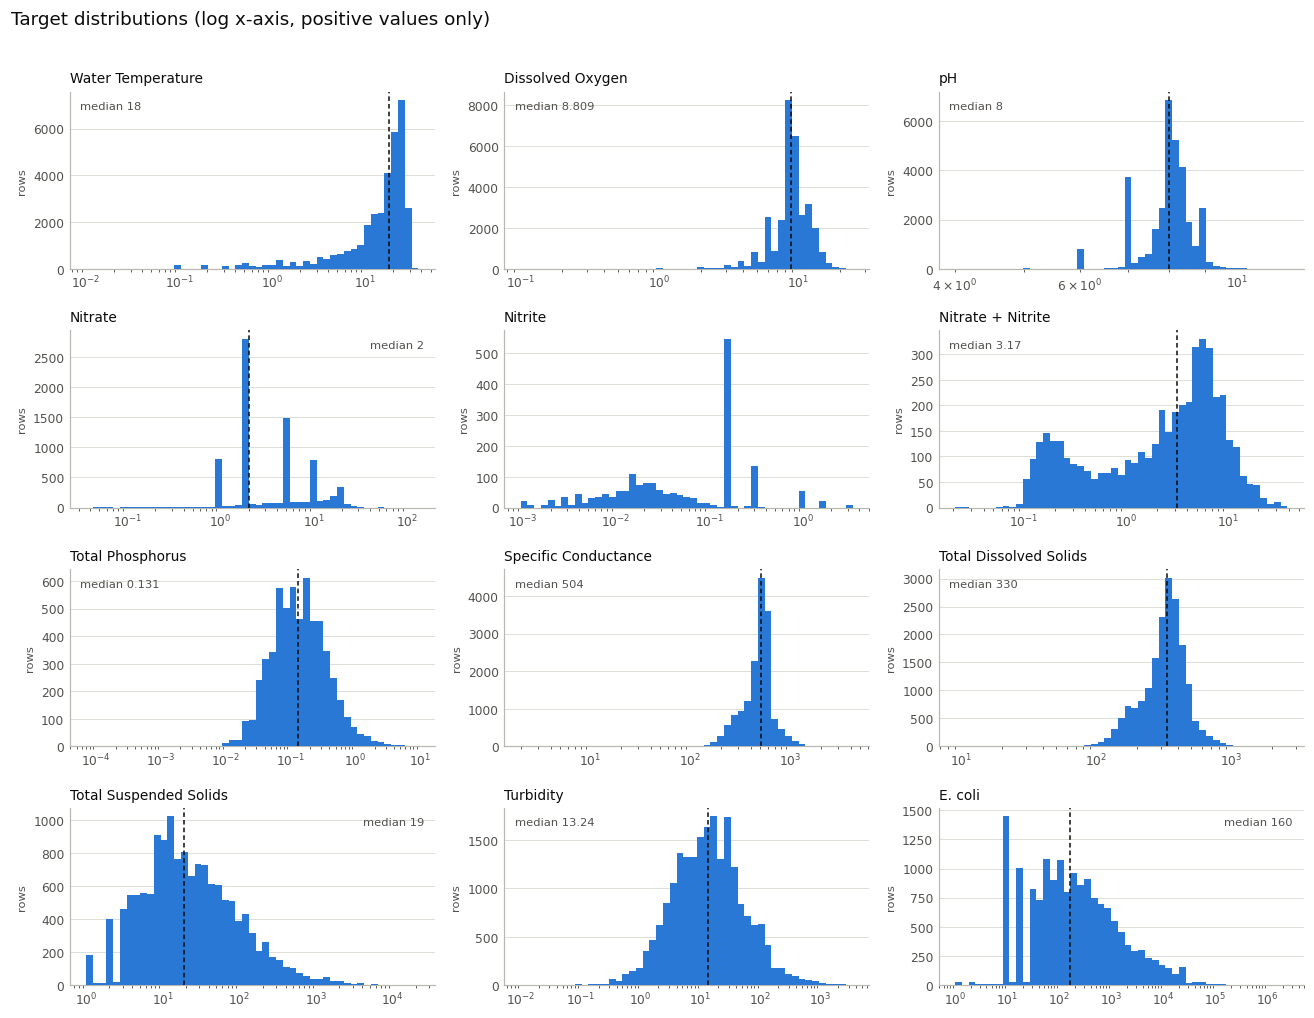

In [19]:
hist_grid(df, TARGET_VALUE_COLS, labels={v: k for k, v in TARGET_COLS.items()},
          log=True, bins=50, title="Target distributions (log x-axis, positive values only)")

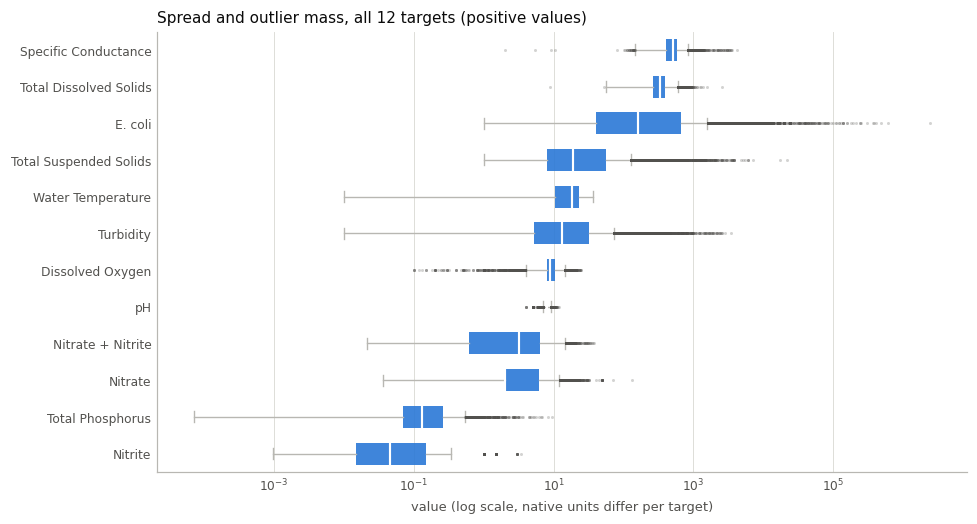

In [20]:
# Boxplots on a shared log axis: relative spread and outlier mass across all 12 targets.
ordered = target_stats["median"].sort_values().index
series, positions, names = [], [], []
for i, name in enumerate(ordered):
    col = TARGET_COLS[name]
    v = pd.to_numeric(df[col], errors="coerce").dropna()
    v = v[v > 0]
    if v.empty:
        continue
    series.append(v.values)
    positions.append(len(series))
    names.append(name)

fig, ax = plt.subplots(figsize=(9.5, 5.2))
bp = ax.boxplot(series, positions=positions, vert=False, widths=0.6, patch_artist=True,
                flierprops=dict(marker="o", markersize=2, markerfacecolor=INK_SOFT,
                                markeredgecolor="none", alpha=0.25),
                medianprops=dict(color=SURFACE, linewidth=1.4),
                whiskerprops=dict(color=AXISLINE, linewidth=0.9),
                capprops=dict(color=AXISLINE, linewidth=0.9))
for patch in bp["boxes"]:
    patch.set(facecolor=BLUE, edgecolor="none", alpha=0.9)
ax.set_yticks(positions, names)
ax.set_xscale("log")
style_axes(ax, axis="x")
ax.set_xlabel("value (log scale, native units differ per target)")
ax.set_title("Spread and outlier mass, all 12 targets (positive values)", loc="left")
plt.show()

### 4.5 Reporting artefacts: value pile-ups

Laboratory data carries censoring. Results below a detection limit are commonly recorded
*at* the limit, and some methods have a hard ceiling (the IDEXX Colilert tray used for
*E. coli* saturates at 2419.6 MPN/100 mL). Both show up as a single value repeating far
more often than a continuous distribution allows — and both bias a regression fit if
left unexamined.

In [21]:
pileups = []
for label, col in TARGET_COLS.items():
    v = pd.to_numeric(df[col], errors="coerce").dropna()
    if v.empty:
        continue
    vc = v.value_counts()
    for value, n in vc.head(3).items():
        pileups.append({
            "target": label,
            "value": value,
            "n": int(n),
            "pct_of_observations": 100 * n / v.size,
            "is_min": value == v.min(),
            "is_max": value == v.max(),
        })
pileup_table = pd.DataFrame(pileups)
pileup_table.to_csv(OUT_DIR / "target_value_pileups.csv", index=False)
print(pileup_table[pileup_table["pct_of_observations"] >= 1].round(2).to_string(index=False))

                target  value    n  pct_of_observations  is_min  is_max
     Water Temperature      0  634                 1.83   False   False
     Water Temperature     20  543                 1.56   False   False
     Water Temperature  21.11  455                 1.31   False   False
      Dissolved Oxygen      8 4049                12.72   False   False
      Dissolved Oxygen     10 2581                 8.11   False   False
      Dissolved Oxygen      6 2148                 6.75   False   False
                    pH      8 5263                16.27   False   False
                    pH      7 3703                11.45   False   False
                    pH      9 2063                 6.38   False   False
               Nitrate      0 4731                38.31    True   False
               Nitrate      2 2747                22.25   False   False
               Nitrate      5 1397                11.31   False   False
               Nitrite      0 9766                84.11    True 

In [22]:
# Zero / non-positive counts matter for any log transform downstream.
zero_tbl = target_stats[["n", "n_zero", "n_negative"]].copy()
zero_tbl["pct_zero"] = 100 * zero_tbl["n_zero"] / zero_tbl["n"]
zero_tbl["pct_nonpositive"] = 100 * (zero_tbl["n_zero"] + zero_tbl["n_negative"]) / zero_tbl["n"]
zero_tbl.sort_values("pct_zero", ascending=False).round(2)

,n,n_zero,n_negative,pct_zero,pct_nonpositive
variable,,,,,
Nitrite,11611,9766,0,84.11,84.11
Nitrate,12348,4731,0,38.31,38.31
Water Temperature,34705,634,83,1.83,2.07
Nitrate + Nitrite,4659,5,0,0.11,0.11
Turbidity,21156,21,0,0.1,0.1
E. coli,15898,3,0,0.02,0.02
Dissolved Oxygen,31825,4,0,0.01,0.01
Specific Conductance,16067,2,0,0.01,0.01
pH,32353,0,0,0,0


### 4.6 Reporting precision

A pile-up on round numbers is the same artefact seen from another angle: how finely was
the variable actually recorded? A target whose values are mostly whole numbers has far
less usable resolution than its range suggests, and the excess mass on integers is
rounding, not signal.

In [23]:
prec_rows = []
for label, col in TARGET_COLS.items():
    v = pd.to_numeric(df[col], errors="coerce").dropna()
    if v.empty:
        continue
    prec_rows.append({
        "target": label,
        "pct_integer_valued": 100 * (v % 1 == 0).mean(),
        "pct_at_most_1_decimal": 100 * ((v * 10) % 1 == 0).mean(),
        "pct_at_most_2_decimals": 100 * ((v * 100) % 1 == 0).mean(),
        "n_unique": int(v.nunique()),
        "unique_per_1000_obs": 1000 * v.nunique() / v.size,
    })
precision = pd.DataFrame(prec_rows).set_index("target").sort_values("pct_integer_valued",
                                                                    ascending=False)
precision.to_csv(OUT_DIR / "target_reporting_precision.csv")
precision.round(1)

,pct_integer_valued,pct_at_most_1_decimal,pct_at_most_2_decimals,n_unique,unique_per_1000_obs
target,,,,,
E. coli,98.8,100,99.8,769,48.4
Total Suspended Solids,91.9,99.5,98.9,792,54.5
Total Dissolved Solids,86.9,97.1,97.3,2394,132.9
Nitrate,86.1,90.8,90,1095,88.7
Nitrite,84.7,86,90.7,299,25.8
Specific Conductance,64.1,94.9,90.9,4012,249.7
Dissolved Oxygen,37.3,72.9,89.2,1810,56.9
pH,36.8,72.7,79.5,773,23.9
Turbidity,31,62.6,88.7,4997,236.2


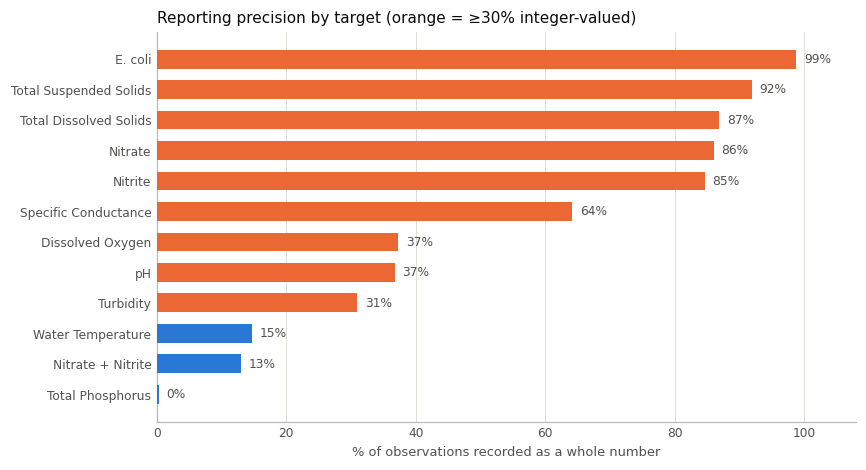

In [24]:
prec = precision["pct_integer_valued"].sort_values()
fig, ax = plt.subplots(figsize=(8.2, 4.6))
colors = [ORANGE if v >= 30 else BLUE for v in prec.values]
ax.barh(prec.index, prec.values, color=colors, height=0.62, zorder=3)
for label, v in zip(prec.index, prec.values):
    ax.text(v + 1.2, label, f"{v:.0f}%", va="center", fontsize=8, color=INK_SOFT)
style_axes(ax, axis="x")
ax.set_xlim(0, 108)
ax.set_xlabel("% of observations recorded as a whole number")
ax.set_title("Reporting precision by target (orange = ≥30% integer-valued)", loc="left")
plt.show()

### 4.7 Extreme upper tails

The largest observed values, checked against the method ceiling where one exists. The
IDEXX Colilert tray used for *E. coli* saturates at **2419.6 MPN/100 mL**; anything above
that is either a diluted re-count (legitimate, and reported at the dilution-scaled value)
or a units/scale error carried through the merge.

In [25]:
tail_rows = []
for label in ["E. coli", "Total Suspended Solids", "Turbidity", "Nitrate", "Nitrite"]:
    v = pd.to_numeric(df[TARGET_COLS[label]], errors="coerce").dropna()
    tail_rows.append({
        "target": label,
        "p99": v.quantile(0.99),
        "p99.9": v.quantile(0.999),
        "max": v.max(),
        "max / p99": v.max() / v.quantile(0.99) if v.quantile(0.99) else np.nan,
        "top_5_values": ", ".join(f"{x:,.4g}" for x in v.nlargest(5)),
    })
tails = pd.DataFrame(tail_rows).set_index("target")
print(tails.round(2).to_string())

COLILERT_CEILING = 2419.6
ec = pd.to_numeric(df[TARGET_COLS["E. coli"]], errors="coerce").dropna()
print(f"\nE. coli vs the Colilert ceiling ({COLILERT_CEILING} MPN/100 mL):")
print(f"  exactly at the ceiling      : {int((ec == COLILERT_CEILING).sum()):,}")
print(f"  above the ceiling           : {int((ec > COLILERT_CEILING).sum()):,} "
      f"({100 * (ec > COLILERT_CEILING).mean():.1f}% of E. coli observations)")
print(f"  at/above 1000x the ceiling  : {int((ec >= 1000 * COLILERT_CEILING).sum()):,}")
print(f"  maximum                     : {ec.max():,.0f}  "
      f"(= {ec.max() / COLILERT_CEILING:,.0f}x the ceiling)")

                           p99   p99.9       max  max / p99                                  top_5_values
target                                                                                                   
E. coli                2.4e+04 1.4e+05  2.42e+06      100.8  2.42e+06, 6.1e+05, 4.9e+05, 4.1e+05, 3.9e+05
Total Suspended Solids   1,178   3,699 2.152e+04      18.27      2.152e+04, 1.71e+04, 7,052, 6,120, 6,040
Turbidity                  430   1,788     3,510       8.16             3,510, 2,872, 2,600, 2,600, 2,513
Nitrate                   20.6      50     132.3       6.42                      132.3, 70.51, 50, 50, 50
Nitrite                    0.3     1.5       3.4      11.33                               3.4, 3, 3, 3, 3

E. coli vs the Colilert ceiling (2419.6 MPN/100 mL):
  exactly at the ceiling      : 8
  above the ceiling           : 1,700 (10.7% of E. coli observations)
  at/above 1000x the ceiling  : 1
  maximum                     : 2,420,000  (= 1,000x the ceiling)


### 4.8 Physical-plausibility bounds

Univariate range checks against known physical limits. A value outside these bounds is a
data error, not a tail observation.

In [26]:
BOUNDS = {
    "Water Temperature":      (-2, 40),      # °C, liquid surface water in Iowa
    "Dissolved Oxygen":       (0, 25),       # mg/L, > ~20 implies supersaturation
    "pH":                     (0, 14),       # std units
    "Nitrate":                (0, None),
    "Nitrite":                (0, None),
    "Nitrate + Nitrite":      (0, None),
    "Total Phosphorus":       (0, None),
    "Specific Conductance":   (0, None),
    "Total Dissolved Solids": (0, None),
    "Total Suspended Solids": (0, None),
    "Turbidity":              (0, None),
    "E. coli":                (0, None),
}

rows = []
for label, (lo, hi) in BOUNDS.items():
    v = pd.to_numeric(df[TARGET_COLS[label]], errors="coerce").dropna()
    below = int((v < lo).sum()) if lo is not None else 0
    above = int((v > hi).sum()) if hi is not None else 0
    rows.append({
        "target": label,
        "plausible_range": f"[{lo}, {hi if hi is not None else '∞'})",
        "observed_min": v.min(),
        "observed_max": v.max(),
        "n_below": below,
        "n_above": above,
        "pct_implausible": 100 * (below + above) / v.size if v.size else np.nan,
    })
bounds_table = pd.DataFrame(rows).set_index("target")
bounds_table.to_csv(OUT_DIR / "target_plausibility_checks.csv")
bounds_table.round(3)

,plausible_range,observed_min,observed_max,n_below,n_above,pct_implausible
target,,,,,,
Water Temperature,"[-2, 40)",-1,37,0,0,0
Dissolved Oxygen,"[0, 25)",0,24.6,0,0,0
pH,"[0, 14)",4,11.76,0,0,0
Nitrate,"[0, ∞)",0,132.3,0,0,0
Nitrite,"[0, ∞)",0,3.4,0,0,0
Nitrate + Nitrite,"[0, ∞)",0,38.4,0,0,0
Total Phosphorus,"[0, ∞)",0,9.5,0,0,0
Specific Conductance,"[0, ∞)",0,"4,200",0,0,0
Total Dissolved Solids,"[0, ∞)",9,"2,580",0,0,0


## 5. The 30 model features

The feature contract in `CLAUDE.md`: 26 station-level base features read straight from
this table, plus 4 temporal features derived from the observation date. Column order is
contractual between training and inference, so these are profiled in contract order.

In [27]:
feature_stats = describe_numeric(df, FEATURE_COLS)
feature_stats.insert(0, "domain", [column_domain(c) for c in FEATURE_COLS])
feature_stats.to_csv(OUT_DIR / "feature_univariate_stats.csv")
feature_stats[["domain", "n", "pct_present", "mean", "std", "min", "median", "max"]].round(3)

,domain,n,pct_present,mean,std,min,median,max
variable,,,,,,,,
LatitudeMeasure,station identity / metadata,48251,100,41.84,0.714,40.39,41.76,43.5
LongitudeMeasure,station identity / metadata,48251,100,-93.08,1.405,-96.63,-93.29,-90.2
distance_to_climate_station_km,climate (PRISM),48251,100,21.5,12.07,0.263,21.21,74.57
distance_to_streamflow_gauge_km,station identity / metadata,48251,100,5.097,4.841,0,4.114,25.83
prism_tmax_c,climate (PRISM),46602,96.58,21.84,9.888,-20.42,25.18,38.95
prism_tmin_c,climate (PRISM),46632,96.64,10.15,9.272,-29.38,12.73,27.09
prism_ppt_mm,climate (PRISM),46629,96.64,3.379,9.436,0,0,131.6
prism_tdmean_c,climate (PRISM),46625,96.63,10.89,9.383,-29.13,13.59,27.26
isu_avg_wind_speed_kts,weather (ISU/ASOS),45079,93.43,7.045,3.522,0,6.634,25.51


In [28]:
feature_stats[["skew", "kurtosis", "n_zero", "n_negative", "n_outlier_iqr",
               "pct_outlier_iqr", "n_unique"]].round(2)

,skew,kurtosis,n_zero,n_negative,n_outlier_iqr,pct_outlier_iqr,n_unique
variable,,,,,,,
LatitudeMeasure,0.47,-0.28,0,0,0,0,1324
LongitudeMeasure,-0.29,-0.47,0,48251,0,0,1326
distance_to_climate_station_km,0.98,1.16,0,0,1042,2.16,1332
distance_to_streamflow_gauge_km,1.01,0.74,0,0,582,1.21,1330
prism_tmax_c,-1.14,0.68,0,1771,1144,2.45,27337
prism_tmin_c,-1.02,0.61,0,7915,687,1.47,27047
prism_ppt_mm,5.06,34.88,29916,0,8842,18.96,9958
prism_tdmean_c,-0.9,0.17,0,7575,521,1.12,27684
isu_avg_wind_speed_kts,0.75,0.7,361,0,842,1.87,8623


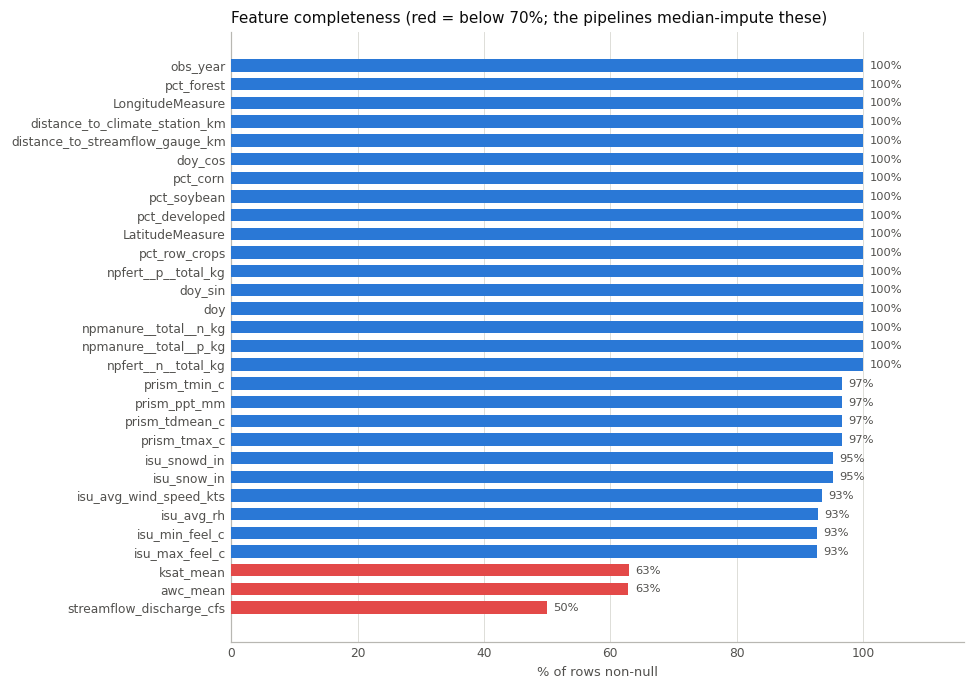

In [29]:
present = feature_stats["pct_present"].sort_values()
fig, ax = plt.subplots(figsize=(8.6, 7.2))
colors = [RED if v < 70 else BLUE for v in present.values]
ax.barh(present.index, present.values, color=colors, height=0.66, zorder=3)
for label, v in zip(present.index, present.values):
    ax.text(v + 1, label, f"{v:.0f}%", va="center", fontsize=7.5, color=INK_SOFT)
style_axes(ax, axis="x")
ax.set_xlim(0, 116)
ax.set_xlabel("% of rows non-null")
ax.set_title("Feature completeness (red = below 70%; the pipelines median-impute these)",
             loc="left", fontsize=10)
plt.show()

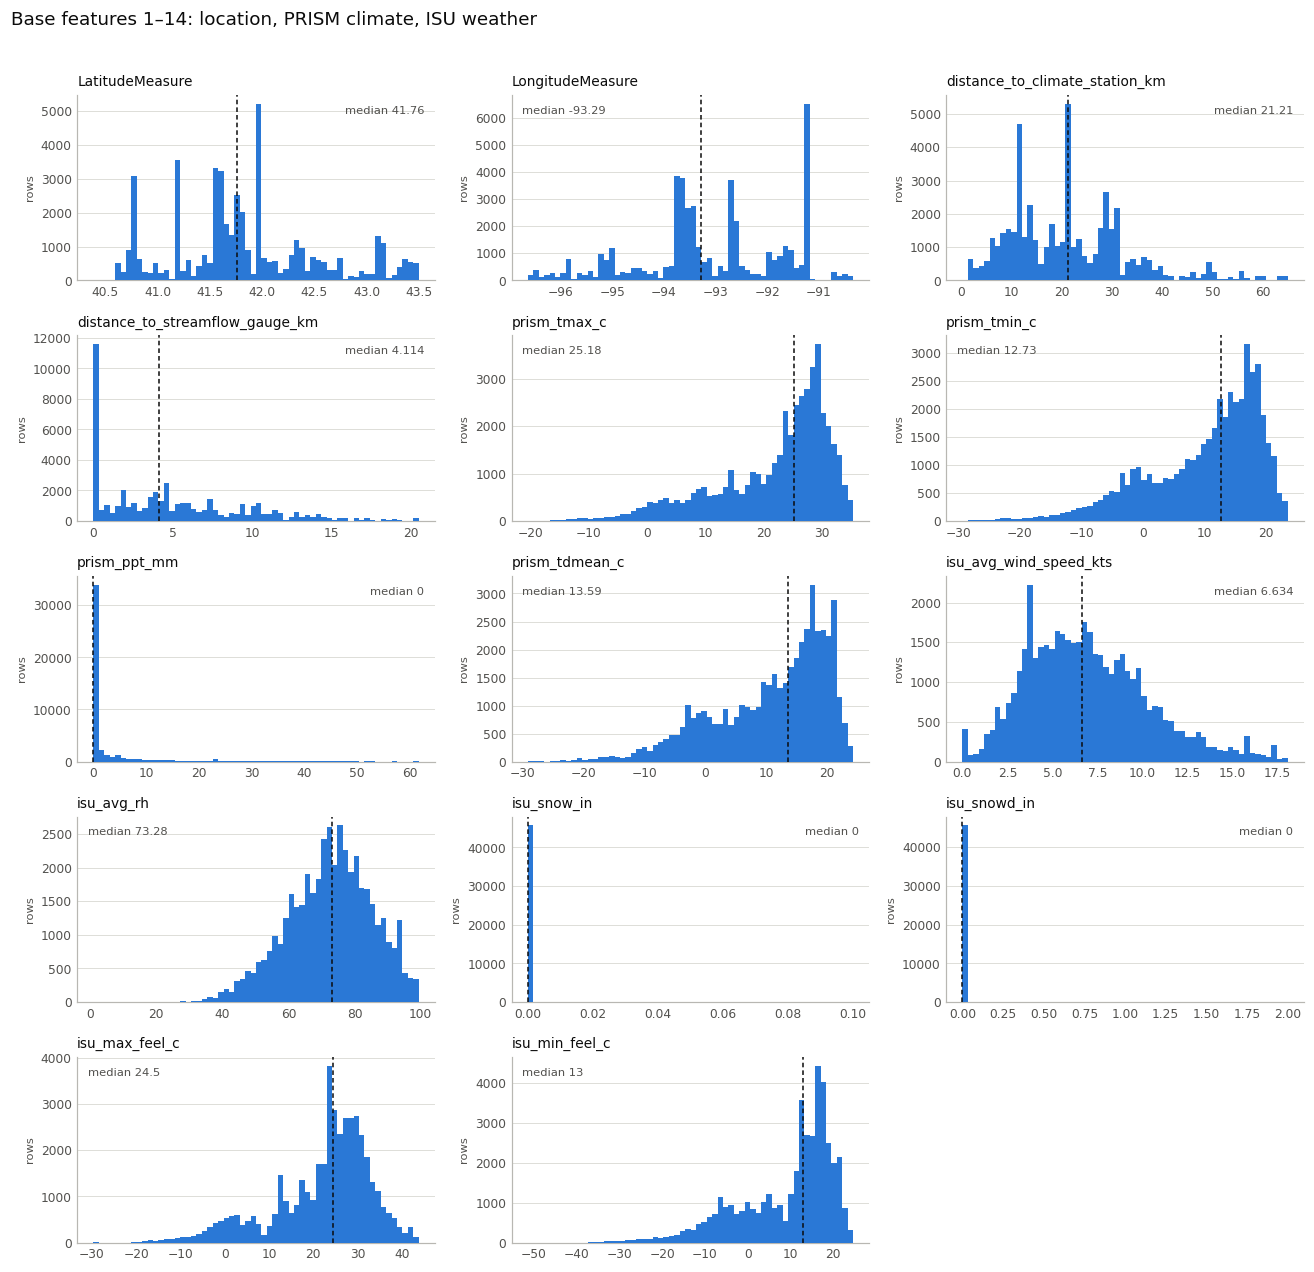

In [30]:
hist_grid(df, BASE_FEATURE_COLS[:14], ncols=3, clip=0.995,
          title="Base features 1–14: location, PRISM climate, ISU weather")

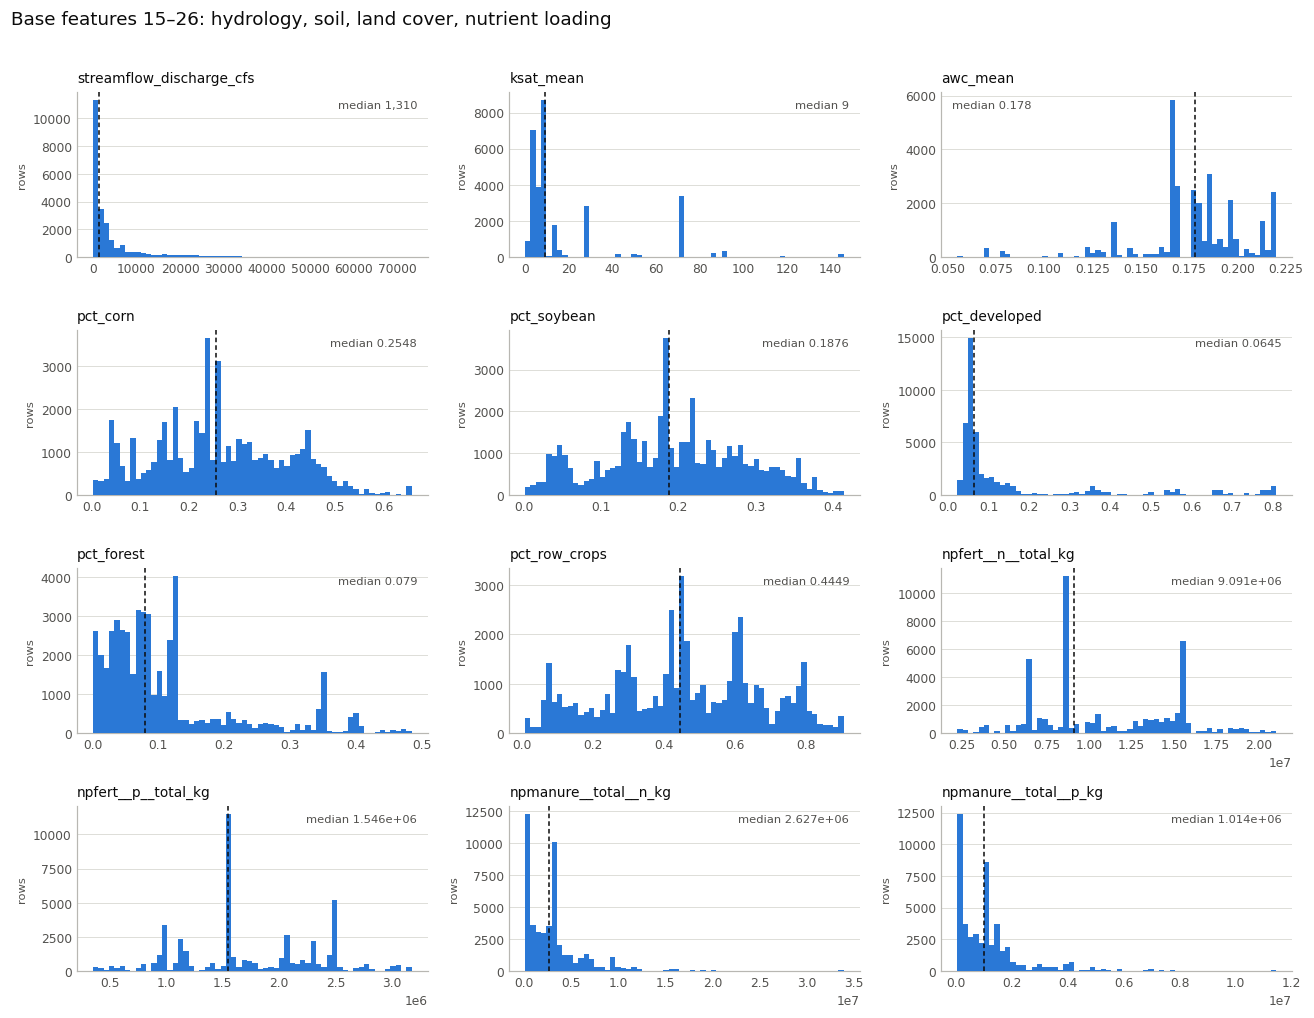

In [31]:
hist_grid(df, BASE_FEATURE_COLS[14:], ncols=3, clip=0.995,
          title="Base features 15–26: hydrology, soil, land cover, nutrient loading")

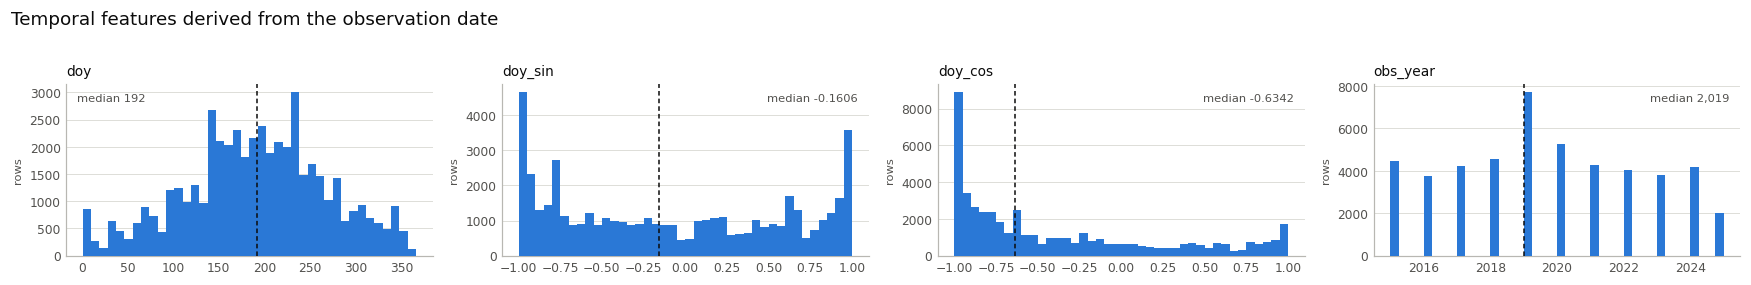

In [32]:
hist_grid(df, TEMPORAL_FEATURE_COLS, ncols=4, bins=40, panel_h=2.6,
          title="Temporal features derived from the observation date")

Several features are heavily skewed or zero-inflated (discharge, snow, snow depth,
developed/forest land-cover fractions). That is fine for the tree-based families, which
are invariant to monotone transforms of a predictor, but it is exactly the condition
under which the linear-regression family is least well specified — the `StandardScaler`
step centres and scales but does not fix skew.

In [33]:
# Degenerate-feature screen: constant, near-constant, or zero-dominated predictors.
screen = []
for c in FEATURE_COLS:
    v = pd.to_numeric(df[c], errors="coerce").dropna()
    top_share = v.value_counts(normalize=True).iloc[0] if not v.empty else np.nan
    screen.append({
        "feature": c,
        "n_unique": int(v.nunique()),
        "modal_value": v.mode().iloc[0] if not v.empty else np.nan,
        "modal_share_pct": 100 * top_share,
        "pct_zero": 100 * (v == 0).mean(),
        "std": v.std(),
    })
screen = pd.DataFrame(screen).set_index("feature").sort_values("modal_share_pct", ascending=False)
screen.round(2).head(12)

,n_unique,modal_value,modal_share_pct,pct_zero,std
feature,,,,,
isu_snowd_in,15,0,99.03,99.03,0.41
isu_snow_in,32,0,98.8,98.8,0.14
prism_ppt_mm,9958,0,64.16,64.16,9.44
ksat_mean,121,9,23.98,0,25.37
npfert__p__total_kg,198,1.546e+06,23.21,0,6.265e+05
npfert__n__total_kg,198,8.738e+06,23.21,0,4.142e+06
obs_year,11,"2,019",15.95,0,2.88
awc_mean,88,0.18,9.83,0,0.03
pct_developed,1002,0.05,7.9,0,0.2


## 6. Categorical and identifier columns

Cardinality first — it separates true categoricals (a handful of levels, usable as
features) from identifiers (one level per station/watershed, usable only as keys).

In [34]:
cat_cols = [c for c in df.columns if str(df[c].dtype) in ("str", "object", "bool")]
cat_summary = (
    pd.DataFrame({
        "domain": [column_domain(c) for c in cat_cols],
        "n_unique": [df[c].nunique() for c in cat_cols],
        "pct_present": [100 * df[c].notna().mean() for c in cat_cols],
        "modal_value": [df[c].mode().iloc[0] if df[c].notna().any() else None for c in cat_cols],
        "modal_share_pct": [100 * df[c].value_counts(normalize=True).iloc[0]
                            if df[c].notna().any() else np.nan for c in cat_cols],
    }, index=pd.Index(cat_cols, name="column"))
    .sort_values("n_unique")
)
cat_summary.to_csv(OUT_DIR / "categorical_summary.csv")
cat_summary.round(2)

,domain,n_unique,pct_present,modal_value,modal_share_pct
column,,,,,
Microcystin_unit,measurement unit,1,6.34,ug/L,100
"Alkalinity, total_unit",measurement unit,1,9.44,mg/L,100
Atrazine_unit,measurement unit,1,3.01,ug/L,100
"Chlorophyll a, free of pheophytin_unit",measurement unit,1,17.95,ug/L,100
Escherichia coli_unit,measurement unit,1,32.95,MPN/100mL,100
Turbidity_unit,measurement unit,1,43.85,NTU,100
Total suspended solids_unit,measurement unit,1,30.1,mg/L,100
Total dissolved solids_unit,measurement unit,1,37.33,mg/L,100
Specific conductance_unit,measurement unit,1,33.3,uS/cm,100


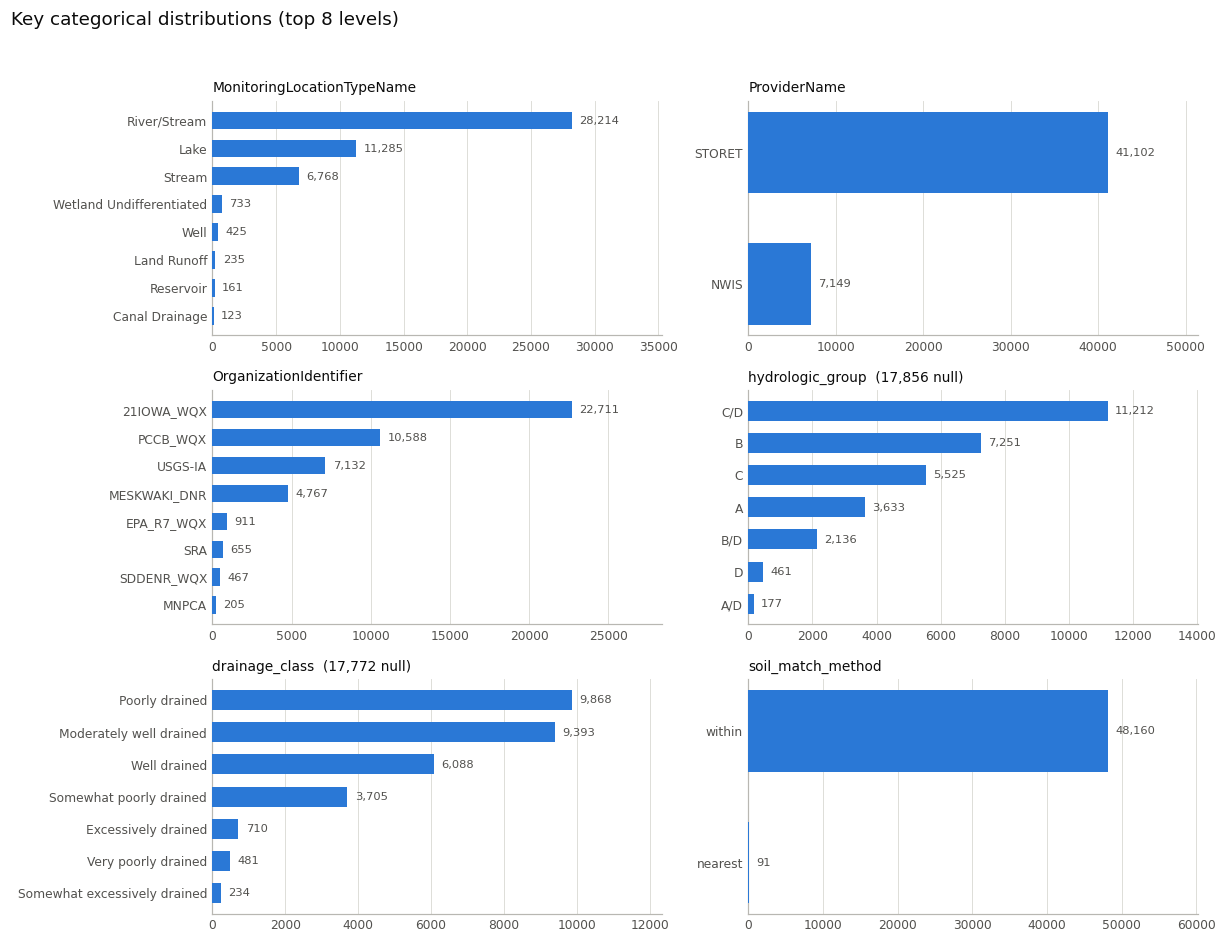

In [35]:
def value_count_panel(cols, ncols=2, top=8, panel_h=2.9, title=None):
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.6 * ncols, panel_h * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, c in zip(axes, cols):
        vc = df[c].value_counts().head(top).sort_values()
        ax.barh([str(i) for i in vc.index], vc.values, color=BLUE, height=0.62, zorder=3)
        for label, v in zip(vc.index, vc.values):
            ax.text(v + vc.max() * 0.02, str(label), f"{v:,}", va="center",
                    fontsize=7.5, color=INK_SOFT)
        style_axes(ax, axis="x")
        ax.set_xlim(0, vc.max() * 1.25)
        n_null = df[c].isna().sum()
        subtitle = f"  ({n_null:,} null)" if n_null else ""
        ax.set_title(f"{c}{subtitle}", loc="left", fontsize=9)
    for ax in axes[len(cols):]:
        ax.set_axis_off()
    if title:
        fig.suptitle(title, x=0.008, ha="left", fontsize=12, color=INK)
    fig.tight_layout(rect=(0, 0, 1, 0.96 if title else 1))
    plt.show()


value_count_panel(["MonitoringLocationTypeName", "ProviderName",
                   "OrganizationIdentifier", "hydrologic_group",
                   "drainage_class", "soil_match_method"],
                  title="Key categorical distributions (top 8 levels)")

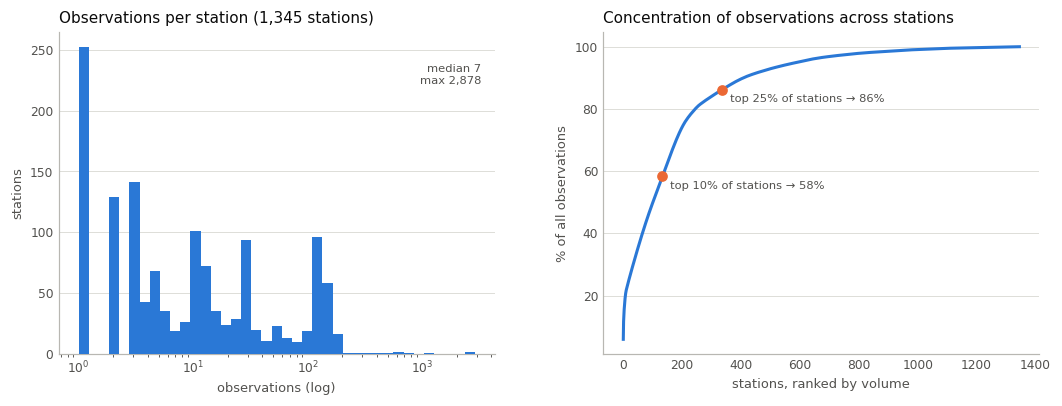

In [36]:
# Observation volume per station — a heavy-tailed count distribution in its own right.
per_station = df[ID_COL].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8), gridspec_kw={"wspace": 0.25})

ax = axes[0]
ax.hist(per_station.values, bins=np.logspace(0, np.log10(per_station.max()), 40),
        color=BLUE, zorder=3)
ax.set_xscale("log")
style_axes(ax)
ax.set_title(f"Observations per station ({per_station.size:,} stations)", loc="left")
ax.set_xlabel("observations (log)")
ax.set_ylabel("stations")
ax.text(0.97, 0.9, f"median {per_station.median():,.0f}\nmax {per_station.max():,}",
        transform=ax.transAxes, ha="right", va="top", fontsize=7.5, color=INK_SOFT)

ax = axes[1]
share = per_station.sort_values(ascending=False).cumsum() / per_station.sum() * 100
ax.plot(np.arange(1, share.size + 1), share.values, color=BLUE, linewidth=2)
style_axes(ax)
ax.set_xlabel("stations, ranked by volume")
ax.set_ylabel("% of all observations")
ax.set_title("Concentration of observations across stations", loc="left")
for q in (0.1, 0.25):
    k = max(int(share.size * q), 1)
    ax.plot([k], [share.iloc[k - 1]], "o", color=ORANGE, markersize=6, zorder=4)
    ax.text(k + share.size * 0.02, share.iloc[k - 1] - 4,
            f"top {q:.0%} of stations → {share.iloc[k - 1]:.0f}%", fontsize=7.5, color=INK_SOFT)
plt.show()

## 7. Temporal coverage

`ActivityStartDateTime` is one variable, but its calendar decomposition — year, month,
day-of-year — is what the model's four temporal features actually see. Sampling effort is
never uniform in environmental monitoring, and the shape of that non-uniformity bounds
what the temporal features can encode.

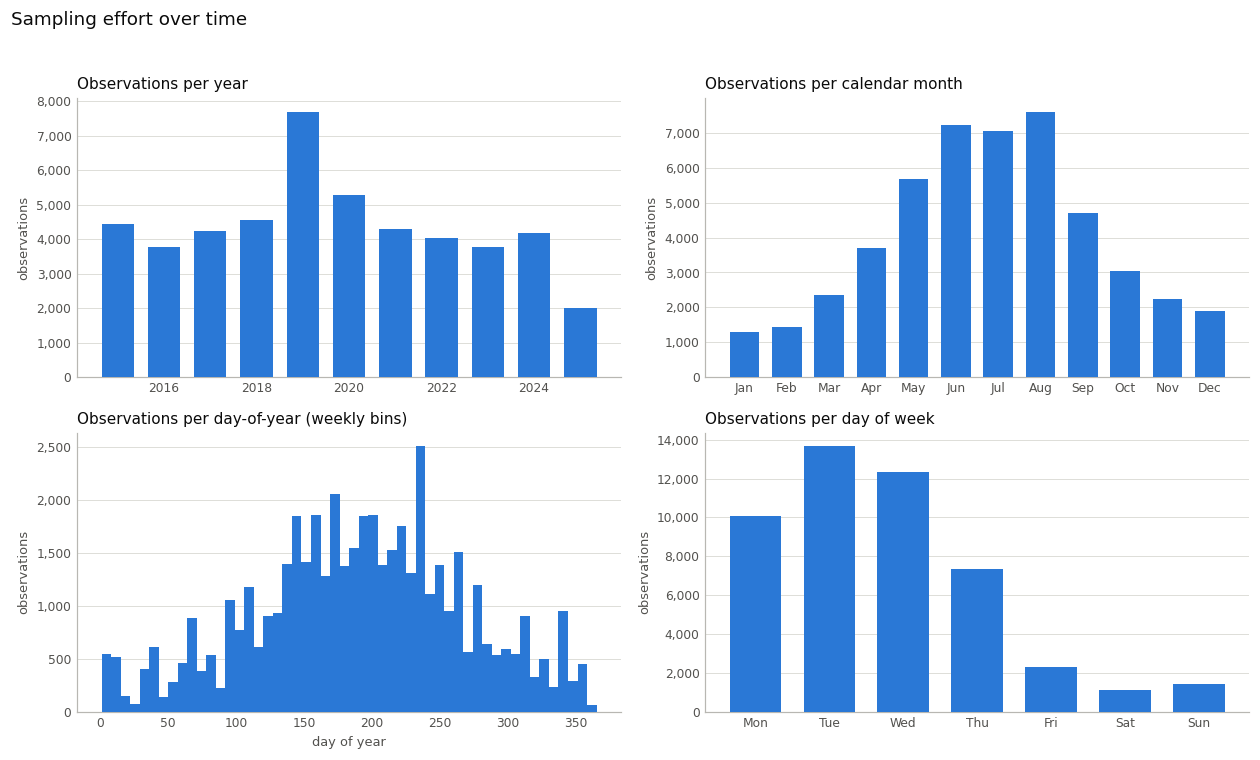

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.0))

by_year = df["obs_year"].value_counts().sort_index()
ax = axes[0, 0]
ax.bar(by_year.index, by_year.values, color=BLUE, width=0.7, zorder=3)
style_axes(ax); thousands(ax)
ax.set_title("Observations per year", loc="left")
ax.set_ylabel("observations")

MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
by_month = df["obs_month"].value_counts().reindex(range(1, 13), fill_value=0)
ax = axes[0, 1]
ax.bar(MONTHS, by_month.values, color=BLUE, width=0.7, zorder=3)
style_axes(ax); thousands(ax)
ax.set_title("Observations per calendar month", loc="left")
ax.set_ylabel("observations")

ax = axes[1, 0]
ax.hist(df["doy"].dropna(), bins=np.arange(1, 368, 7), color=BLUE, zorder=3)
style_axes(ax); thousands(ax)
ax.set_title("Observations per day-of-year (weekly bins)", loc="left")
ax.set_xlabel("day of year")
ax.set_ylabel("observations")

ax = axes[1, 1]
dow = df[DATE_COL].dt.dayofweek.value_counts().reindex(range(7), fill_value=0)
ax.bar(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], dow.values, color=BLUE,
       width=0.7, zorder=3)
style_axes(ax); thousands(ax)
ax.set_title("Observations per day of week", loc="left")
ax.set_ylabel("observations")

fig.suptitle("Sampling effort over time", x=0.008, ha="left", fontsize=12, color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

In [38]:
season_tbl = (
    pd.DataFrame({"month": df["obs_month"]})
    .assign(season=lambda d: pd.cut(d["month"], bins=[0, 2, 5, 8, 11, 12],
                                    labels=["Winter", "Spring", "Summer", "Fall", "Winter "],
                                    ordered=False))
    ["season"].value_counts()
)
season_tbl = season_tbl.groupby(season_tbl.index.str.strip(), observed=True).sum()
season_pct = (100 * season_tbl / season_tbl.sum()).round(1).rename("pct_of_observations")
pd.concat([season_tbl.rename("observations"), season_pct], axis=1)

,observations,pct_of_observations
season,,
Fall,9987,20.7
Spring,11738,24.3
Summer,21894,45.4
Winter,4632,9.6


## 8. Automated data-quality flags

A single screen over every column, so nothing in the 315 goes unchecked. Each rule is a
univariate one.

In [39]:
numeric_cols = df.select_dtypes(include="number").columns
flags = []

for c in all_null:
    flags.append(("all null", c, "column is empty — drop from the merge output"))
for c in constant:
    flags.append(("constant", c, f"single value {df[c].dropna().iloc[0]!r} — zero information"))
for c in near_empty:
    flags.append(("<5% populated", c, f"{completeness.loc[c, 'pct_present']:.2f}% non-null"))

for c in numeric_cols:
    v = pd.to_numeric(df[c], errors="coerce").dropna()
    if v.empty:
        continue
    sk = v.skew()
    if np.isfinite(sk) and abs(sk) > 10:
        flags.append(("extreme skew", c, f"skew = {sk:,.1f}"))
    if v.size > 100:
        modal_share = v.value_counts(normalize=True).iloc[0]
        if modal_share > 0.5 and v.nunique() > 1:
            flags.append(("value pile-up", c,
                          f"{modal_share:.0%} of values equal {v.mode().iloc[0]!r}"))

flag_table = pd.DataFrame(flags, columns=["flag", "column", "detail"])
flag_table["domain"] = [column_domain(c) for c in flag_table["column"]]
flag_table = flag_table[["flag", "domain", "column", "detail"]].sort_values(["flag", "column"])
flag_table.to_csv(OUT_DIR / "data_quality_flags.csv", index=False)

print(flag_table["flag"].value_counts().to_string(), "\n")
print(f"{len(flag_table)} flags written to {OUT_DIR / 'data_quality_flags.csv'}")
print(flag_table.head(40).to_string(index=False))

flag
constant         45
value pile-up    33
extreme skew     15
<5% populated     9 

102 flags written to /Users/owenm/Documents/Owens_files/College Stuff/Research Projects/STEEN Fellowship Project 2026/workspace/Water-Quality-Prediction/src/04_eda/outputs/data_quality_flags.csv
         flag                      domain                                                     column                                               detail
<5% populated            measurement unit                                              Atrazine_unit                                       3.01% non-null
<5% populated       wq non-target analyte                                             Atrazine_value                                       3.01% non-null
<5% populated           crop yield (NASS)                      cropyield__barley__production__census                                       0.05% non-null
<5% populated           crop yield (NASS)  cropyield__corn_traditional_or_indian__production__census  

In [40]:
# Flags restricted to the columns that actually reach a model.
in_contract = flag_table[flag_table["column"].isin(FEATURE_COLS + TARGET_VALUE_COLS)]
print(f"{len(in_contract)} flags fall on modeling columns:")
print(in_contract.to_string(index=False) if len(in_contract) else "none")

10 flags fall on modeling columns:
         flag             domain                       column                              detail
 extreme skew          wq target       Escherichia coli_value                         skew = 84.9
 extreme skew          wq target                Nitrite_value                         skew = 13.5
 extreme skew          wq target Total suspended solids_value                         skew = 29.6
 extreme skew          wq target              Turbidity_value                         skew = 12.2
 extreme skew weather (ISU/ASOS)                  isu_snow_in                         skew = 32.4
 extreme skew weather (ISU/ASOS)                 isu_snowd_in                         skew = 18.8
value pile-up          wq target                Nitrite_value 84% of values equal np.float64(0.0)
value pile-up weather (ISU/ASOS)                  isu_snow_in 99% of values equal np.float64(0.0)
value pile-up weather (ISU/ASOS)                 isu_snowd_in 99% of values equal n

## 9. Findings

### Structure

- **48,251 rows × 315 columns**, 1,345 monitoring stations, 555 HUC-12 watersheds, 99 of
  Iowa's 99 counties, 21 organizations, **2015-01-02 → 2025-12-25**.
- The grain is clean: every `(station, datetime)` key appears exactly once, no fully
  duplicated rows, no null station ids or timestamps. Distributions below can be read as
  "per observation" without qualification.
- `StateCode` is constant at 19 — the Iowa-only scope holds throughout the table.
- The table is dominated by county-year agricultural context: 155 of 315 columns come
  from three NASS blocks (`chemapp__` 98, `livestock__` 29, `cropyield__` 28), and those
  are also the emptiest (mean completeness 27%, 19%, 30%). The columns the models
  actually use are the well-populated ones.

### Missingness

- **No column is entirely empty**, but 45 are constant. Of those, 23 are the `_unit`
  columns (one unit per analyte — see below), one is `StateCode`, and the remaining 21
  are sparse NASS series where the only rows present all share a single state-level value
  (e.g. `chemapp__corn__herbicide__24-d_2-ehe_lb` = 225,000 lb for all 7.8% of rows that
  have it). Those 21 carry zero within-Iowa variance and cannot inform any model.
- Nine columns are populated on <5% of rows, mostly minor crops (barley, spring wheat,
  rye) and angora goats.
- Feature completeness splits cleanly: 15 of the 26 base features are 100% present, the
  PRISM/ISU weather block is 93–97%, and three are materially incomplete —
  `streamflow_discharge_cfs` (**50.0%**), `ksat_mean` (**63.0%**), `awc_mean` (**62.9%**).
  Half of all discharge values reaching a model are median-imputed by the pipeline's
  `SimpleImputer`, which is worth remembering when a discharge-driven signal looks weak.

### Targets

- **Units are unambiguous.** All 12 targets are reported in exactly one unit, with no
  value ever missing its unit. There is no hidden unit mixture.
- **Coverage spans 7×**: Water Temperature 34,705 rows (71.9%) down to Nitrate + Nitrite
  4,659 (9.7%) and Total Phosphorus 5,886 (12.2%). The three sparsest targets have an
  order of magnitude less training data than the top three.
- **Two distributional families.** Temperature, pH and DO are near-symmetric and bounded
  (|skew| ≤ 0.8). Everything else is right-skewed, several extremely so: E. coli
  (skew 84.9), Total Suspended Solids (29.6), Nitrite (13.5), Turbidity (12.2). For those,
  the mean is not a useful summary — E. coli's mean is 1,845 against a median of 160.
- **Zero-inflation is concentrated in the nitrogen species**: Nitrite is 84.1% zeros and
  Nitrate 38.3%. These are almost certainly non-detects recorded as 0, not true absences.
  Any log transform must handle them explicitly, and a regression fit to a variable that
  is 84% a single value is fitting the 16%.
- **Coarse reporting precision.** 86% of Nitrate values are whole numbers, and pH and
  Dissolved Oxygen are ~37% integer-valued (pH = exactly 8.0 on 16.3% of observations,
  DO = exactly 8.0 on 12.7%). pH is not measured to whole units in a lab — this is
  rounding upstream, and it puts a floor on achievable RMSE regardless of model.
- **E. coli's upper tail needs a decision.** 1,700 observations (10.7%) exceed the 2,419.6
  IDEXX Colilert ceiling, and the maximum — **2,420,000 MPN/100 mL** — sits at ~1,000× it,
  100× the 99th percentile (24,000) and 4× the next-largest value (610,000). The top
  values are all round (610,000 / 490,000 / 410,000), consistent with dilution-scaled
  re-counts, but the single 2.42M reading is far more likely a scale artefact than a
  count. It alone drives much of the 84.9 skew and would dominate any squared-error loss.
- **No value violates a physical bound**: temperature −1 to 37 °C, pH 4 to 11.8, DO 0 to
  24.6 mg/L, and no negative concentrations anywhere. The 83 sub-zero temperatures are
  plausible winter readings.

### Features

- Six of the 30 model features are severely degenerate or skewed:
  `isu_snowd_in` (99.0% zero), `isu_snow_in` (98.8% zero), `prism_ppt_mm` (64.2% zero —
  correct for daily precipitation, but it makes the variable effectively binary plus a
  tail), `streamflow_discharge_cfs` (skew 6.2), `npmanure__total__n_kg`/`_p_kg` (skew 4.4).
- The nutrient-budget and land-cover features are county- or watershed-level, so they take
  few distinct values across 48k rows (`npfert__n__total_kg`: 198 unique values, modal
  share 23%). They vary spatially, not per observation.
- `LatitudeMeasure`/`LongitudeMeasure` are effectively station identifiers (1,324 and
  1,326 unique values for 1,345 stations); tree models will use them to memorise stations.
- Skew is harmless for Random Forest and HistGradientBoosting but not for the linear
  family — `StandardScaler` centres and scales, it does not fix a skew of 32.

### Sampling design

- Observations are heavily **summer-weighted**: 45.4% June–August against 9.6%
  December–February. `doy_sin`/`doy_cos` are therefore estimated from a very uneven
  calendar, and winter predictions rest on a tenth of the data.
- Station volume is extremely heavy-tailed: the median station has **7** observations
  while the busiest has **2,878**, and the top 10% of stations account for **58%** of all
  observations (top 25% → 86%). An unstratified random train/test split therefore leaks
  the same handful of stations across both sides, and station-level memorisation will
  read as generalisation.

### Consequences for modeling

1. Nitrite (84% zeros) and, to a lesser degree, Nitrate (38%) are poor fits for plain
   regression; a hurdle/two-part formulation or a detection-limit-aware target is the
   honest treatment.
2. E. coli needs its scale artefact resolved and a log target before its metrics mean
   anything.
3. `streamflow_discharge_cfs` at 50% present is the weakest link in the feature contract.
4. Any resampling should be stratified by station and by season.

## 10. Red flags

Six issues that should be resolved before the current metrics are quoted anywhere. The
first four are visible in the univariate views above. The last two are **not** univariate
findings — they are consequences of the distributions above for code outside this
notebook (`src/05_modeling/*.ipynb` and `app.py`), verified here because the univariate
structure is exactly what makes them dangerous.

| # | Red flag | Severity | Where |
|---|----------|----------|-------|
| 1 | Random train/test split leaks stations across the split | **critical** | training notebooks |
| 2 | Inference freezes weather features at a station's last visit | **critical** | `app.py` |
| 3 | `error_rate` is a function of the zero fraction, not model quality | **high** | `model_metrics.csv` |
| 4 | Nitrite (84% zeros) is modelled as a continuous variable | **high** | data + training |
| 5 | E. coli's tail mixes real dilution counts with a scale artefact | medium | data |
| 6 | Nutrient-budget features are up to 8 years stale | medium | data |

The three cells below produce the evidence for flags 1–3.

### 10.1 Which "station" features are actually per-observation?

`app.py` builds its inference matrix from one frozen row per station
(`groupby(...).last()`). That is only sound for features that are genuinely station
attributes. Decomposing each base feature's variance into between-station and
within-station parts settles which is which.

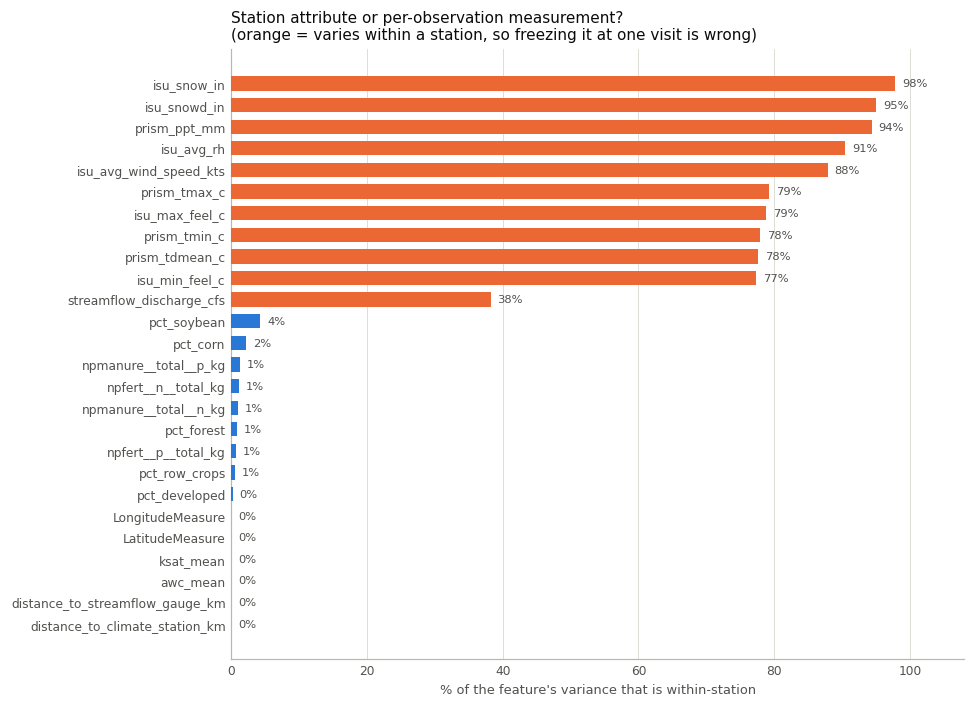

                          within_station_share  n_unique                    kind
feature                                                                         
streamflow_discharge_cfs                 0.382      3534  varies per observation
isu_min_feel_c                           0.774      3128  varies per observation
prism_tdmean_c                           0.777     27684  varies per observation
prism_tmin_c                             0.779     27047  varies per observation
isu_max_feel_c                           0.788      4253  varies per observation
prism_tmax_c                             0.792     27337  varies per observation
isu_avg_wind_speed_kts                   0.879      8623  varies per observation
isu_avg_rh                               0.905     19321  varies per observation
prism_ppt_mm                             0.944      9958  varies per observation
isu_snowd_in                             0.951        15  varies per observation
isu_snow_in                 

In [41]:
rows = []
for c in BASE_FEATURE_COLS:
    v = df[[ID_COL, c]].dropna()
    total_var = v[c].var()
    between_var = v.groupby(ID_COL, observed=True)[c].transform("mean").var()
    rows.append({
        "feature": c,
        "within_station_share": 1 - between_var / total_var if total_var else np.nan,
        "n_unique": int(v[c].nunique()),
    })
variance_split = pd.DataFrame(rows).set_index("feature").sort_values("within_station_share")
variance_split["kind"] = np.where(variance_split["within_station_share"] > 0.30,
                                  "varies per observation", "station attribute")
variance_split.to_csv(OUT_DIR / "feature_variance_decomposition.csv")

fig, ax = plt.subplots(figsize=(8.6, 7.2))
vals = variance_split["within_station_share"] * 100
colors = [ORANGE if v > 30 else BLUE for v in vals]
ax.barh(vals.index, vals.values, color=colors, height=0.66, zorder=3)
for label, v in zip(vals.index, vals.values):
    ax.text(v + 1, label, f"{v:.0f}%", va="center", fontsize=7.5, color=INK_SOFT)
style_axes(ax, axis="x")
ax.set_xlim(0, 108)
ax.set_xlabel("% of the feature's variance that is within-station")
ax.set_title("Station attribute or per-observation measurement?\n"
             "(orange = varies within a station, so freezing it at one visit is wrong)",
             loc="left", fontsize=10)
plt.show()

print(variance_split[variance_split["within_station_share"] > 0.30].round(3).to_string())

In [42]:
# What app.py actually freezes: one row per station, taken from the last record.
g = df.sort_values(DATE_COL).groupby(ID_COL, sort=False)
final_row = g.tail(1).set_index(ID_COL)[BASE_FEATURE_COLS]
skipna_last = g[BASE_FEATURE_COLS].last()          # what groupby.last() returns

SENTINEL = -9e18                                    # so NaN == NaN compares equal
composite = ~(final_row.fillna(SENTINEL)
              == skipna_last.reindex(final_row.index).fillna(SENTINEL)).all(axis=1)

age_days = (pd.Timestamp.today().normalize() - g[DATE_COL].max()).dt.days
frozen_month = g[DATE_COL].max().dt.month

print(f"stations                                        : {len(final_row):,}")
print(f"  whose frozen row mixes values from >1 visit    : {int(composite.sum()):,} "
      f"({100 * composite.mean():.1f}%)")
print(f"age of the frozen record, in days:  median {age_days.median():,.0f}  "
      f"p90 {age_days.quantile(0.9):,.0f}  max {age_days.max():,.0f}")
print("\nCalendar month the frozen weather comes from:")
print((100 * frozen_month.value_counts(normalize=True).sort_index())
      .round(1).rename_axis("month").to_frame("pct_of_stations").T.to_string())

stations                                        : 1,345
  whose frozen row mixes values from >1 visit    : 220 (16.4%)
age of the frozen record, in days:  median 1,410  p90 3,697  max 4,173

Calendar month the frozen weather comes from:
month            1   2   3   4   5   6   7   8    9    10  11  12
pct_of_stations 0.1 0.4 0.4 7.1 5.9 5.7 6.5  20 26.1 15.5 5.2   7


### 10.2 Station leakage under the training split

The training notebooks use `train_test_split(test_size=0.2, random_state=42)` with no
grouping. Combined with §6's finding that the top 10% of stations hold 58% of
observations — and with latitude/longitude in the feature set at ~1 unique value per
station — this puts nearly every test row's station in the training set too.

In [43]:
from sklearn.model_selection import train_test_split

leak = []
for label, col in TARGET_COLS.items():
    f = df[[col, ID_COL]].dropna(subset=[col])
    if len(f) < 100:
        continue
    idx = np.arange(len(f))
    tr, te = train_test_split(idx, test_size=0.2, random_state=42)  # the notebooks' split
    st = f[ID_COL].to_numpy()
    seen = set(st[tr])
    leak.append({
        "target": label,
        "n_test": len(te),
        "pct_test_rows_with_station_in_train": 100 * np.isin(st[te], list(seen)).mean(),
        "n_test_stations": len(set(st[te])),
        "n_stations_total": f[ID_COL].nunique(),
    })
leakage = pd.DataFrame(leak).set_index("target")
leakage.to_csv(OUT_DIR / "split_leakage_check.csv")
print(leakage.round(1).to_string())
print(f"\nmean across targets: "
      f"{leakage['pct_test_rows_with_station_in_train'].mean():.1f}% of test rows sit at a "
      f"station the model already saw in training.")

                        n_test  pct_test_rows_with_station_in_train  n_test_stations  n_stations_total
target                                                                                                
Water Temperature         6941                                 99.3              697               999
Dissolved Oxygen          6365                                 99.3              650               909
pH                        6471                                 99.1              751              1107
Nitrate                   2470                                 99.1              190               278
Nitrite                   2323                                 99.2              165               229
Nitrate + Nitrite          932                                 99.4              260               367
Total Phosphorus          1178                                 98.2              311               453
Specific Conductance      3214                                 99.5      

### 10.3 What `error_rate` is actually measuring

The notebooks report a symmetric MAPE. Its per-row term is
`2·|y − ŷ| / (|y| + |ŷ|)`, which saturates at **200%** whenever the true value is 0 and
the prediction is not. So for a zero-inflated target the metric has a floor set by the
zero fraction alone — before the model does anything.

In [44]:
metrics = pd.read_csv(REPO_ROOT / "src" / "05_modeling" / "model_metrics.csv")
zero_share = {label: (pd.to_numeric(df[col], errors="coerce").dropna() == 0).mean()
              for label, col in TARGET_COLS.items()}

cmp = (metrics[metrics["model"] == "Random Forest"]
       .set_index("target")[["r2", "error_rate"]]
       .assign(pct_zero=lambda d: 100 * pd.Series(zero_share).reindex(d.index),
               smape_floor_from_zeros=lambda d: 2 * d["pct_zero"])
       .sort_values("pct_zero", ascending=False))
cmp["reported_minus_floor"] = cmp["error_rate"] - cmp["smape_floor_from_zeros"]
print(cmp.round({"r2": 3, "error_rate": 1, "pct_zero": 1,
                 "smape_floor_from_zeros": 1, "reported_minus_floor": 1}).to_string())

                          r2  error_rate  pct_zero  smape_floor_from_zeros  reported_minus_floor
target                                                                                          
Nitrite                0.086       175.5      84.1                   168.2                   7.3
Nitrate                0.674       103.2      38.3                    76.6                  26.6
Water Temperature      0.952        17.5       1.8                     3.7                  13.8
Nitrate + Nitrite      0.656          59       0.1                     0.2                  58.8
Turbidity              0.275          64       0.1                     0.2                  63.8
E. coli                 0.26       115.8         0                       0                 115.8
Dissolved Oxygen       0.596        13.3         0                       0                  13.2
Specific Conductance   0.886           7         0                       0                   6.9
pH                     0.526  

### The list

**1. Station leakage makes every reported R² optimistic (critical).**
99.1–99.7% of test rows sit at a station that is also in the training set, and latitude
and longitude are model inputs with ~1 unique value per station. A tree can identify the
station from coordinates and recall its typical level. This inflates exactly the targets
that are most station-determined — Specific Conductance (RF R² 0.886) and Total Dissolved
Solids (0.824) are chemically dominated by local geology, and their scores are far more
plausible as memorisation than as prediction. **Fix:** re-split with `GroupShuffleSplit` /
`GroupKFold` grouped on `MonitoringLocationIdentifier`, and re-report. Expect the numbers
to fall. If the intended use is *"predict at this known station on a future date"*, then a
temporal split is the honest test instead; either way the current split answers neither
question.

**2. The dashboard serves weather from the wrong date (critical).**
79% of `prism_tmax_c`'s variance and 79% of `isu_max_feel_c`'s is *within* station — these
are per-observation measurements, not station attributes. `app.py` freezes all 26 base
features at the station's last visit and pairs them with fresh `doy`/`obs_year` from the
user's chosen date. So a January prediction is served with the station's last-visit
weather, and 83% of frozen records come from April–October (35% from August–September
alone). The frozen record has a median age of 1,410 days. Worse, `groupby.last()` skips
NaNs per column, so 16.4% of station rows are composites stitched from more than one
visit — a combination of conditions that never co-occurred. The seasonal signal the user
thinks they are varying is contradicted by frozen summer weather. **Fix:** either supply
date-matched climate/weather at inference (forecast or climatology for the chosen date),
or drop the per-observation weather features from the served feature set and be explicit
that the model is climatological.

**3. `error_rate` is largely reporting the zero fraction (high).**
Nitrite is 84.1% zeros, which forces a symmetric-MAPE floor of ~168% regardless of the
model; the reported figure is 175.5%. Nitrate: 38.3% zeros → ~77% floor, reported 103%.
These numbers cannot be compared across targets and should not be read as "the model is
175% wrong". **Fix:** report MAE and RMSE against the target's own scale, and drop sMAPE
for any target with a meaningful zero mass.

**4. Nitrite is not a regression problem as posed (high).**
84% of its values are 0 and the rest span three orders of magnitude. Its R² is 0.01–0.09
across all three families, which is the correct answer to the wrong question. **Fix:**
either model P(detect) and the magnitude given detection separately, or drop Nitrite from
the dashboard rather than shipping a model that cannot beat the mean. The same argument
applies in weaker form to Nitrate (38% zeros) and Total Phosphorus (R² 0.33).

**5. E. coli's tail is a mixture of two things (medium).**
1,700 values (10.7%) exceed the Colilert ceiling. Most are round numbers consistent with
dilution-scaled re-counts, but the maximum — 2,420,000, at ~1,000× the ceiling and 100×
the 99th percentile — is not a plausible count. The training notebooks' `valid_range` of
(0, 1e6) silently drops that one reading but keeps 610,000; the dashboard applies no such
filter. **Fix:** decide explicitly what the censoring rule is, model `log10(E. coli)`, and
state the rule in the notebook rather than leaving it inside a range tuple.

**6. Nutrient-budget features are stale by construction (medium).**
`np_base_year` is only ever 2012 or 2017, and `np_years_stale` runs from 0 to **8 years**.
Four of the 26 base features (`npfert__*`, `npmanure__*`) therefore describe a county's
nutrient loading up to eight years away from the observation being modelled. **Fix:** at
minimum expose `np_years_stale` as a feature so a model can discount the stale rows;
better, note the limitation wherever those features' importances are reported.

### Not red flags, checked and cleared

- Units are single-valued per analyte; no hidden unit mixtures.
- No physically impossible values in any target.
- Record grain is exactly one row per station-visit; no duplicates.
- The CDL land-cover `year` matches the observation year on 100% of rows.
- `StateCode` is constant at 19 — the Iowa-only scope holds throughout.

### Files written

| File | Contents |
|---|---|
| `outputs/column_completeness.csv` | Non-null count, %, dtype, cardinality and domain for all 315 columns |
| `outputs/target_units.csv` | Reported unit(s) per modeling target |
| `outputs/target_univariate_stats.csv` | Full univariate statistics for the 12 targets |
| `outputs/target_value_pileups.csv` | Three most frequent values per target (censoring / ceiling detection) |
| `outputs/target_plausibility_checks.csv` | Observed range vs. physical bounds |
| `outputs/feature_univariate_stats.csv` | Full univariate statistics for the 30 model features |
| `outputs/categorical_summary.csv` | Cardinality and modal level for every string/bool column |
| `outputs/data_quality_flags.csv` | Automated flags across all columns |
| `outputs/feature_variance_decomposition.csv` | Within- vs between-station variance for the 26 base features |
| `outputs/split_leakage_check.csv` | Station overlap between train and test under the notebooks' split |

### Next step

Bivariate analysis: target–feature relationships, feature–feature collinearity within and
across source domains, and the spatial/temporal structure that univariate views cannot show.